# 1. Cargar el dataset

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance


In [2]:
# Cargamos el archivo parquet

df_original= pd.read_parquet('cartera_q1_2026_final.parquet')

df_autos = df_original[df_original['ramo'] == 'Autos'].copy()
df_autos.info()
filas, columnas = df_autos.shape
print()
print(f"Quedaron exactamente {filas:,} registros (filas) y {columnas} campos (columnas).")

<class 'pandas.core.frame.DataFrame'>
Index: 14752 entries, 1 to 49997
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_poliza              14752 non-null  object        
 1   num_poliza             14752 non-null  object        
 2   nombre                 14752 non-null  category      
 3   apellido_paterno       14752 non-null  category      
 4   apellido_materno       14752 non-null  category      
 5   rfc                    14752 non-null  object        
 6   edad                   14752 non-null  int8          
 7   sexo                   14752 non-null  category      
 8   estado_civil           14752 non-null  category      
 9   ocupacion              13568 non-null  category      
 10  ramo                   14752 non-null  category      
 11  plan                   14752 non-null  category      
 12  fecha_emision          14752 non-null  datetime64[ns]
 13  fecha_

In [3]:
# --- CONTEO RÁPIDO DE VARIABLES CON NULOS ---
# 1. Cuántas columnas tienen al menos un valor nulo
cols_con_nulos = df_autos.isnull().any().sum()
print(f"Número de variables con al menos un dato nulo: {cols_con_nulos}")

# 2. Detalle de cuántos nulos tiene cada columna (solo las que tienen nulos)
null_counts = df_autos.isnull().sum()
detalle_nulos = null_counts[null_counts > 0]

print("\n--- Detalle de variables con nulos ---")
if not detalle_nulos.empty:
    print(detalle_nulos)
else:
    print("¡No hay variables con datos nulos! Tu dataset está limpio.")

Número de variables con al menos un dato nulo: 4

--- Detalle de variables con nulos ---
ocupacion          1184
motivo_baja       14006
codigo_postal       450
tipo_principal    10333
dtype: int64


In [4]:
# ==============================================================================
# MEMORIA DE IMPUTACIÓN Y LIMPIEZA DE DATOS (df_autos)
# ==============================================================================
# NOTAS DE CONTROL
# ==============================================================================
# • df_autos['ocupacion']: Seguirá siendo tipo 'category'. Los nulos se vuelven 'Desconocido'.
# • df_autos['codigo_postal']: Seguirá siendo 'float64'. Se llena con el CP más común de su municipio/estado.
# • df_autos['status_poliza']: Mantiene intacto su tipo 'category' original. No sufre cambios.
# • df_autos['motivo_baja']: Seguirá siendo tipo 'category'. Los nulos se llenan con el texto de 'status_poliza'.
# • df_autos['tipo_principal']: Seguirá siendo tipo 'object'. Los nulos se llenan con el texto 'No identificado'.
#   Al mantener 'object' y 'category' separados, Pandas permite hacer análisis descriptivos
#   y tablas cruzadas (crosstab) de forma nativa sin ningún conflicto.
# =====================================================================
# 1. Variable: 'ocupacion' (Tipo: category)
# Criterio: Imputar valores nulos con "Desconocido".
# ------------------------------------------------------------------------------
if 'Desconocido' not in df_autos['ocupacion'].cat.categories:
    df_autos['ocupacion'] = df_autos['ocupacion'].cat.add_categories(['Desconocido'])
df_autos['ocupacion'] = df_autos['ocupacion'].fillna('Desconocido')


# 2. Variable: 'motivo_baja' (Tipo: category)
# Criterio: Usar el valor de 'status_poliza'.
# Solución técnica: Conversión a 'object' para evitar TypeError por categorías no idénticas.
# ------------------------------------------------------------------------------
df_autos['motivo_baja'] = df_autos['motivo_baja'].astype('object')
df_autos['motivo_baja'] = df_autos['motivo_baja'].fillna(df_autos['status_poliza'])
df_autos['motivo_baja'] = df_autos['motivo_baja'].astype('category')


# 3. Variable: 'codigo_postal' (Tipo: float64)
# Criterio: Imputar con la moda calculada por 'estado' y 'municipio'.
# ------------------------------------------------------------------------------
moda_cp = df_autos.groupby(['estado', 'municipio'])['codigo_postal'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)
df_autos['codigo_postal'] = df_autos['codigo_postal'].fillna(moda_cp)


# 4. Variable: 'tipo_principal' (Tipo: object)
# Criterio: Imputar con "No identificado".
# ------------------------------------------------------------------------------
df_autos['tipo_principal'] = df_autos['tipo_principal'].fillna('No identificado')

# ==============================================================================
# CONFIRMACIÓN DE INTEGRIDAD
# ==============================================================================
print("Imputación finalizada. Verificación de tipos:")
print(df_autos[['ocupacion', 'motivo_baja', 'codigo_postal', 'tipo_principal']].dtypes)
print("\nConteo de nulos restantes:")
print(df_autos[['ocupacion', 'motivo_baja', 'codigo_postal', 'tipo_principal']].isna().sum())

Imputación finalizada. Verificación de tipos:
ocupacion         category
motivo_baja       category
codigo_postal      float64
tipo_principal      object
dtype: object

Conteo de nulos restantes:
ocupacion         0
motivo_baja       0
codigo_postal     0
tipo_principal    0
dtype: int64


In [5]:
#Base de datos sin nulos

df_autos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14752 entries, 1 to 49997
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_poliza              14752 non-null  object        
 1   num_poliza             14752 non-null  object        
 2   nombre                 14752 non-null  category      
 3   apellido_paterno       14752 non-null  category      
 4   apellido_materno       14752 non-null  category      
 5   rfc                    14752 non-null  object        
 6   edad                   14752 non-null  int8          
 7   sexo                   14752 non-null  category      
 8   estado_civil           14752 non-null  category      
 9   ocupacion              14752 non-null  category      
 10  ramo                   14752 non-null  category      
 11  plan                   14752 non-null  category      
 12  fecha_emision          14752 non-null  datetime64[ns]
 13  fecha_

In [6]:
# DEFINICION DE PALETA DE COLORES PARA TODO EL PROYECTO.

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex
import numpy as np

# 1. Define tu paleta base
colores_base = ["#2C3E50", "#1ABC9C", "#95A5A6", "#E67E22", "#34495E"]

def obtener_paleta_hex(n):
    """Devuelve una lista de n colores en formato HEX."""
    if n <= 1: return [colores_base[0]]
    cmap = LinearSegmentedColormap.from_list("custom_exec", colores_base, N=n)
    # Convertimos los colores generados a formato HEX para que sirvan en CSS (Tablas)
    return [to_hex(cmap(i)) for i in np.linspace(0, 1, n)]

In [7]:
# 2. Configuración global: Que muestre absolutamente todo
pd.set_option('display.max_rows', None)        # Mostrar todas las filas
pd.set_option('display.max_columns', None)     # Mostrar todas las columnas
pd.set_option('display.max_colwidth', None)    # No cortar texto en celdas

## Definición de variables features y targets

In [8]:
# --- 1. CONFIGURACIÓN Y DEFINICIONES ---
# (Tus listas originales integradas)
cols_features = [
    'edad', 'sexo', 'estado_civil', 'ocupacion', 'plan',
    'fecha_emision', 'fecha_inicio_vigencia', 'fecha_fin_vigencia',
    'num_renovaciones', 'status_poliza', 'motivo_baja', 'canal_venta',
    'marca_vehiculo', 'modelo_vehiculo', 'tipo_vehiculo', 'suma_asegurada',
    'deducible', 'prima_total', 'forma_pago', 'estado', 'codigo_postal',
    'region', 'monto_reclamado', 'tiene_abierto', 'prima_mensual',
    'nivel_riesgo', 'anio_emision', 'mes_emision', 'trimestre',
    'segmento_prima_fijo', 'cuartil_prima', 'anio_poliza',
    'antiguedad_vehiculo', 'g_edad'
]

cols_target = ['prima_neta', 'n_siniestros', 'monto_pagado']
cols_exclude = ['ramo', 'agente_id', 'rfc', 'nombre_agente', 'comision_pct',
                'tipo_principal', 'loss_ratio', 'comision_est', 'cod_ramo',
                'municipio', 'tipo_agente', 'ramo_desde_codigo']

In [9]:
# Convertir a formato fecha si no lo están
df_autos['fecha_inicio_vigencia'] = pd.to_datetime(df_autos['fecha_inicio_vigencia'])
# Si tienes el año del modelo, la antigüedad es el año actual - año del modelo
# O si tienes una fecha de fin de vigencia:
df_autos['antiguedad_vehiculo'] = df_autos['fecha_inicio_vigencia'].dt.year - df_autos['modelo_vehiculo']

In [10]:
# 1. Definimos los límites de los grupos (bins)
cortes = [17, 30, 45, 60, np.inf]

# 2. Definimos los nombres de las categorías correspondientes
etiquetas = ['18-30', '31-45', '46-60', '61+']

# 3. Aplicamos pd.cut para crear la nueva columna
df_autos['g_edad'] = pd.cut(df_autos['edad'], bins=cortes, labels=etiquetas, right=True)

# Modelos para estimar las variable prima_neta

## XGBoost

Primero analizaremos el modelo incluyendo la suma asegurada

In [11]:
# Clasificación de variables

cols_target = ['prima_neta','n_siniestros','monto_pagado']

cols_feature_num = ['edad', 'suma_asegurada']
cols_feature_cat = ['plan','sexo','canal_venta','marca_vehiculo','tipo_vehiculo','modelo_vehiculo','estado','nivel_riesgo']
cols_features = cols_feature_num + cols_feature_cat

cols_pii = df_autos.columns.drop(cols_features).tolist()

all_columns = len(cols_features) + len(cols_target) + len(cols_pii)

print(f"All Colums: {all_columns}")

All Colums: 57


In [12]:
## Preparación del conjunto de datos

TARGET_COLUMNS = ['prima_neta','n_siniestros','monto_pagado']

TARGET = "prima_neta"
SEED  = 20260618
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

X_raw = df_autos[cols_features]
y     = df_autos[TARGET]

# Codificación one-hot de categóricas (drop_first=True evita multicolinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

# Split 80/20 en train/test; random_state fija una partición reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Verificar que no hay targets en X
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} está en X"
print("✓ Ningún target en X")
assert "id_poliza_sin" not in X.columns
print("✓ id_poliza_sin excluido")

Features tras OHE: 52 columnas
Ejemplos de nuevas columnas: ['edad', 'suma_asegurada', 'modelo_vehiculo', 'plan_20 anios', 'plan_Amplia'] ...

Train: 11,801 filas | Test: 2,951 filas
✓ Ningún target en X
✓ id_poliza_sin excluido


In [13]:
# Entrenamiento de los modelos

xgb_conserv = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=20,
    subsample=1.0,
    random_state=SEED,
    tree_method='hist',
    device='cuda'
)

# Entrenamiento del modelo
xgb_conserv.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Predicciones
y_pred_conserv = xgb_conserv.predict(X_test)

# Evaluación
rmse_conserv = np.sqrt(mean_squared_error(y_test, y_pred_conserv))
r2_conserv   = r2_score(y_test, y_pred_conserv)

print(f"XGBoost conservador (lr=0.05, depth=3): RMSE={rmse_conserv:,.0f} MXN | R²={r2_conserv:.4f}")

xgb_flex = XGBRegressor(
    n_estimators=200,
    learning_rate=0.15,
    max_depth=5,
    subsample=0.8,
    random_state=SEED,
    tree_method='hist',
    device='cuda'
)

xgb_flex.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
y_pred_flex = xgb_flex.predict(X_test)

rmse_flex = np.sqrt(mean_squared_error(y_test, y_pred_flex))
r2_flex   = r2_score(y_test, y_pred_flex)
print(f"XGBoost flexible (lr=0.15, depth=5):    RMSE={rmse_flex:,.0f} MXN | R²={r2_flex:.4f}")

XGBoost conservador (lr=0.05, depth=3): RMSE=1,419 MXN | R²=0.9671
XGBoost flexible (lr=0.15, depth=5):    RMSE=1,466 MXN | R²=0.9649


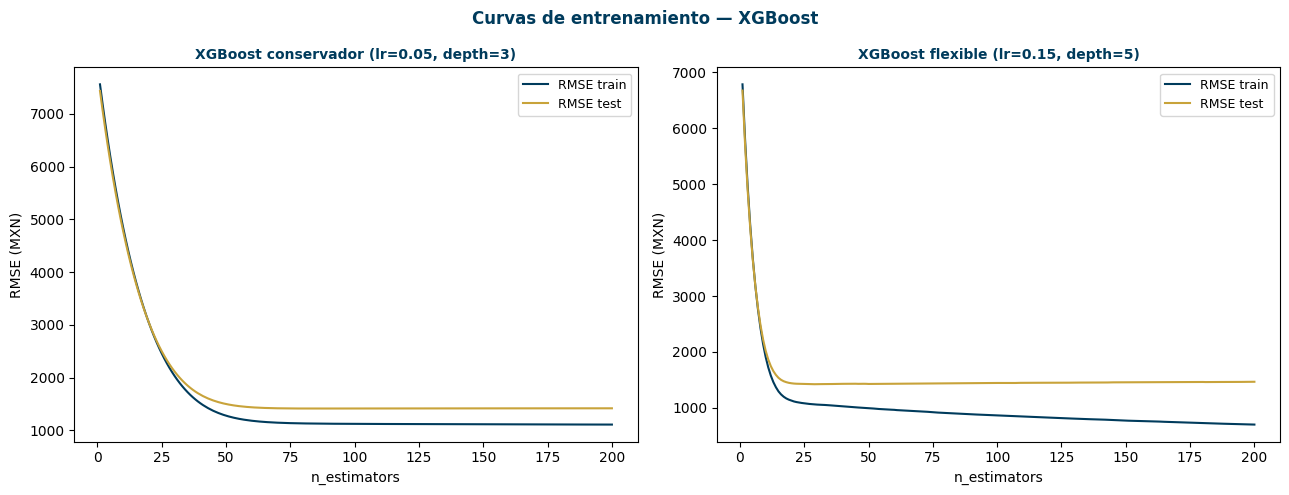

Observación: la configuración flexible muestra mayor gap train/test,
señal de sobreajuste incipiente a medida que aumentan los árboles.


In [14]:
# XGBoost grafica

# Extracción de los resultados (reemplaza a staged_predict)
res_conserv = xgb_conserv.evals_result()
rmse_tr_c = res_conserv['validation_0']['rmse'] # Error en train
rmse_te_c = res_conserv['validation_1']['rmse'] # Error en test

res_flex = xgb_flex.evals_result()
rmse_tr_f = res_flex['validation_0']['rmse']
rmse_te_f = res_flex['validation_1']['rmse']

# Definimos el rango del eje X (1 a 200 árboles)
n_range = range(1, len(rmse_tr_c) + 1)

# Creación de los gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tr, te, titulo in [
    (axes[0], rmse_tr_c, rmse_te_c, "XGBoost conservador (lr=0.05, depth=3)"),
    (axes[1], rmse_tr_f, rmse_te_f, "XGBoost flexible (lr=0.15, depth=5)"),
]:
    ax.plot(n_range, tr, color=NAVY, linewidth=1.5, label="RMSE train")
    ax.plot(n_range, te, color=GOLD, linewidth=1.5, label="RMSE test")
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("RMSE (MXN)")
    ax.set_title(titulo, fontsize=10, fontweight="bold", color=NAVY)
    ax.legend(fontsize=9)

fig.suptitle("Curvas de entrenamiento — XGBoost",
             fontsize=12, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

print("Observación: la configuración flexible muestra mayor gap train/test,")
print("señal de sobreajuste incipiente a medida que aumentan los árboles.")

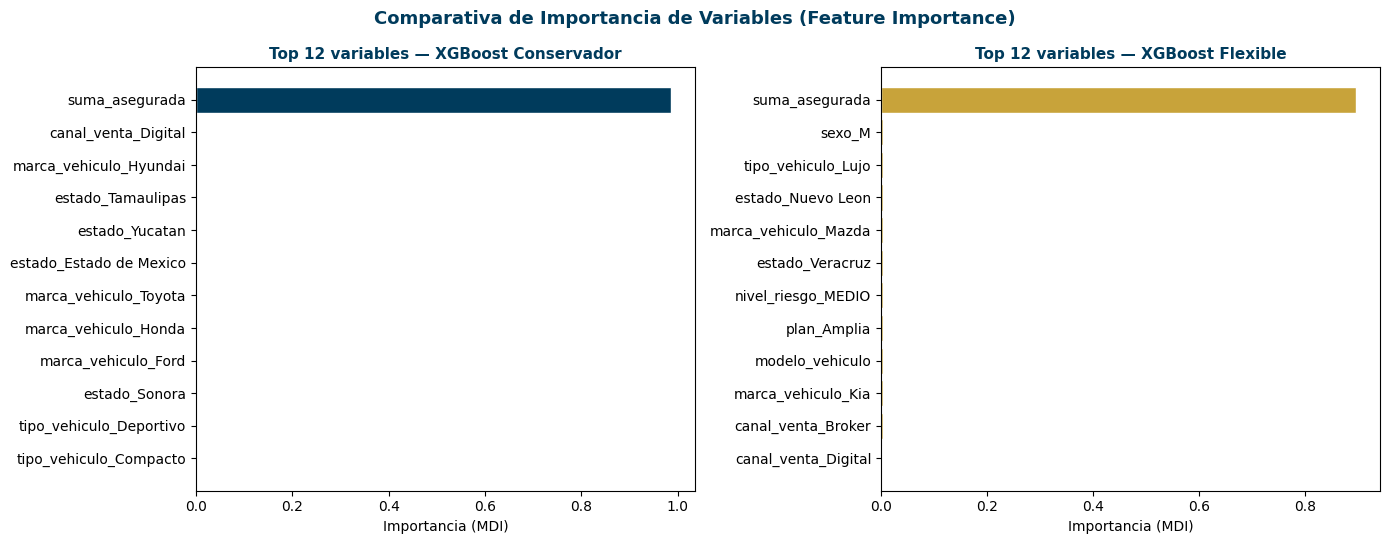

In [15]:
# 1. Extraer importancias del modelo conservador
import_conserv = pd.DataFrame({
    "Feature": X_train.columns,
    "Importancia": xgb_conserv.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

# 2. Extraer importancias del modelo flexible
import_flex = pd.DataFrame({
    "Feature": X_train.columns,
    "Importancia": xgb_flex.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

# 3. Crear la figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Gráfico 1: Modelo Conservador ---
axes[0].barh(import_conserv["Feature"], import_conserv["Importancia"],
             color=NAVY, edgecolor="white")
axes[0].set_xlabel("Importancia (MDI)")
axes[0].set_title("Top 12 variables — XGBoost Conservador",
                  fontsize=11, fontweight="bold", color=NAVY)
axes[0].invert_yaxis() # Para que la más importante quede arriba

# --- Gráfico 2: Modelo Flexible ---
axes[1].barh(import_flex["Feature"], import_flex["Importancia"],
             color=GOLD, edgecolor="white") # Usamos GOLD para contrastar
axes[1].set_xlabel("Importancia (MDI)")
axes[1].set_title("Top 12 variables — XGBoost Flexible",
                  fontsize=11, fontweight="bold", color=NAVY)
axes[1].invert_yaxis()

# Ajustes finales de diseño
fig.suptitle("Comparativa de Importancia de Variables (Feature Importance)",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

Como vemos la variable mas importante es la suma asegurada, como ya lo veniamos diciendo

Ahora, haremos el mismo ejercicio, pero quitando la suma asegurada

In [16]:
# Clasificación de variables

cols_target = ['prima_neta','n_siniestros','monto_pagado']

cols_feature_num = ['edad']
cols_feature_cat = ['plan','sexo','canal_venta','marca_vehiculo','tipo_vehiculo','modelo_vehiculo','estado','nivel_riesgo']

cols_features = cols_feature_num + cols_feature_cat

cols_pii = df_autos.columns.drop(cols_features).tolist()

all_columns = len(cols_features) + len(cols_target) + len(cols_pii)
print(f"All Colums: {all_columns}")

All Colums: 57


In [17]:
## Preparación del conjunto de datos

TARGET_COLUMNS = ['prima_neta','n_siniestros','monto_pagado']

TARGET = "prima_neta"
SEED  = 20260618
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

X_raw = df_autos[cols_features]
y     = df_autos[TARGET]

# Codificación one-hot de categóricas (drop_first=True evita multicolinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

# Split 80/20 en train/test; random_state fija una partición reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Verificar que no hay targets en X
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} está en X"
print("✓ Ningún target en X")
assert "id_poliza_sin" not in X.columns
print("✓ id_poliza_sin excluido")

Features tras OHE: 51 columnas
Ejemplos de nuevas columnas: ['edad', 'modelo_vehiculo', 'plan_20 anios', 'plan_Amplia', 'plan_Amplia Plus'] ...

Train: 11,801 filas | Test: 2,951 filas
✓ Ningún target en X
✓ id_poliza_sin excluido


In [18]:
# Entrenamiento de los modelos

xgb_conserv = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=20,
    subsample=1.0,
    random_state=SEED,
    tree_method='hist',
    device='cuda'
)

# Entrenamiento del modelo
xgb_conserv.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Predicciones
y_pred_conserv = xgb_conserv.predict(X_test)

# Evaluación
rmse_conserv = np.sqrt(mean_squared_error(y_test, y_pred_conserv))
r2_conserv   = r2_score(y_test, y_pred_conserv)

print(f"XGBoost conservador (lr=0.05, depth=3): RMSE={rmse_conserv:,.0f} MXN | R²={r2_conserv:.4f}")

xgb_flex = XGBRegressor(
    n_estimators=200,
    learning_rate=0.15,
    max_depth=5,
    subsample=0.8,
    random_state=SEED,
    tree_method='hist',
    device='cuda'
)

xgb_flex.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
y_pred_flex = xgb_flex.predict(X_test)

rmse_flex = np.sqrt(mean_squared_error(y_test, y_pred_flex))
r2_flex   = r2_score(y_test, y_pred_flex)
print(f"XGBoost flexible (lr=0.15, depth=5):    RMSE={rmse_flex:,.0f} MXN | R²={r2_flex:.4f}")

XGBoost conservador (lr=0.05, depth=3): RMSE=7,852 MXN | R²=-0.0085
XGBoost flexible (lr=0.15, depth=5):    RMSE=8,101 MXN | R²=-0.0736


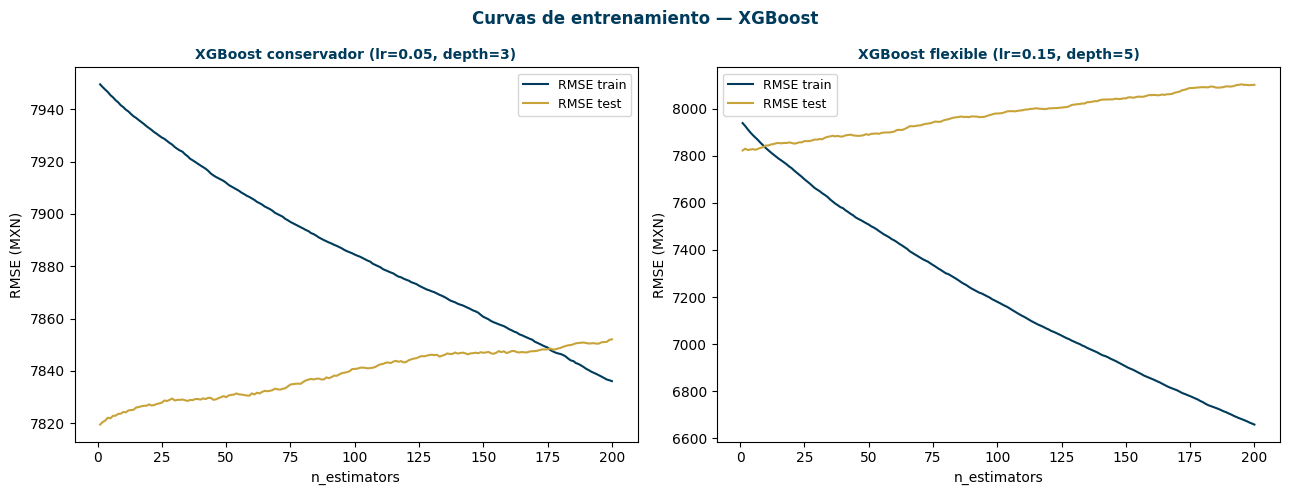

In [19]:
# XGBoost grafica

# Extracción de los resultados (reemplaza a staged_predict)
res_conserv = xgb_conserv.evals_result()
rmse_tr_c = res_conserv['validation_0']['rmse'] # Error en train
rmse_te_c = res_conserv['validation_1']['rmse'] # Error en test

res_flex = xgb_flex.evals_result()
rmse_tr_f = res_flex['validation_0']['rmse']
rmse_te_f = res_flex['validation_1']['rmse']

# Definimos el rango del eje X (1 a 200 árboles)
n_range = range(1, len(rmse_tr_c) + 1)

# Creación de los gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tr, te, titulo in [
    (axes[0], rmse_tr_c, rmse_te_c, "XGBoost conservador (lr=0.05, depth=3)"),
    (axes[1], rmse_tr_f, rmse_te_f, "XGBoost flexible (lr=0.15, depth=5)"),
]:
    ax.plot(n_range, tr, color=NAVY, linewidth=1.5, label="RMSE train")
    ax.plot(n_range, te, color=GOLD, linewidth=1.5, label="RMSE test")
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("RMSE (MXN)")
    ax.set_title(titulo, fontsize=10, fontweight="bold", color=NAVY)
    ax.legend(fontsize=9)

fig.suptitle("Curvas de entrenamiento — XGBoost",
             fontsize=12, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

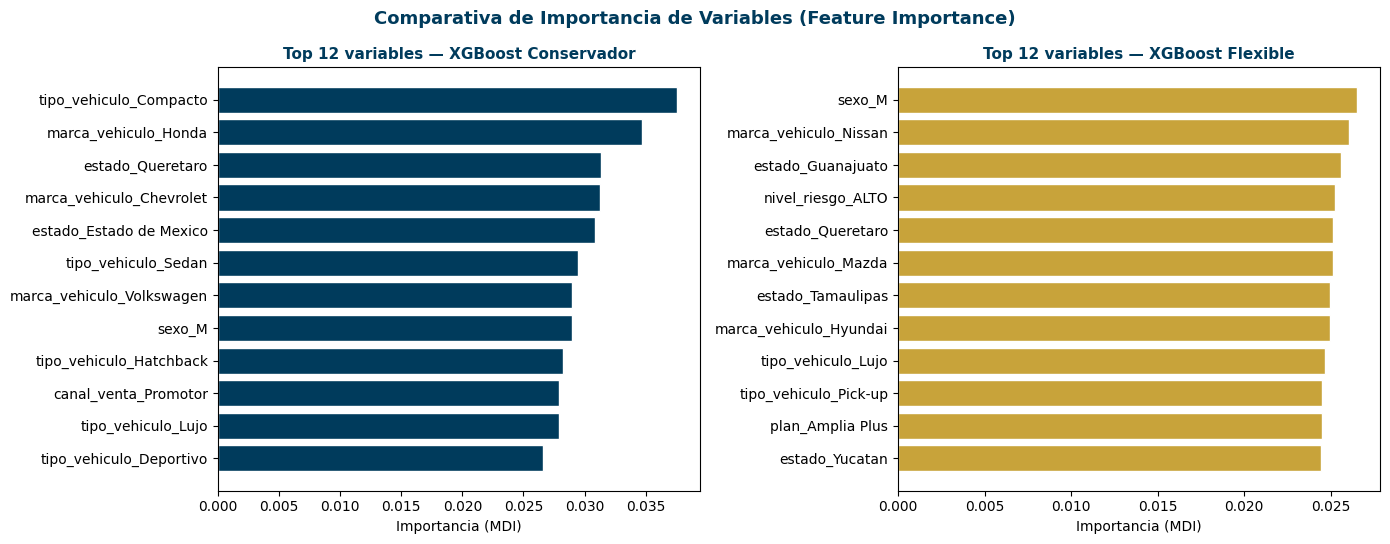

In [20]:
# 1. Extraer importancias del modelo conservador
import_conserv = pd.DataFrame({
    "Feature": X_train.columns,
    "Importancia": xgb_conserv.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

# 2. Extraer importancias del modelo flexible
import_flex = pd.DataFrame({
    "Feature": X_train.columns,
    "Importancia": xgb_flex.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

# 3. Crear la figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Gráfico 1: Modelo Conservador ---
axes[0].barh(import_conserv["Feature"], import_conserv["Importancia"],
             color=NAVY, edgecolor="white")
axes[0].set_xlabel("Importancia (MDI)")
axes[0].set_title("Top 12 variables — XGBoost Conservador",
                  fontsize=11, fontweight="bold", color=NAVY)
axes[0].invert_yaxis() # Para que la más importante quede arriba

# --- Gráfico 2: Modelo Flexible ---
axes[1].barh(import_flex["Feature"], import_flex["Importancia"],
             color=GOLD, edgecolor="white") # Usamos GOLD para contrastar
axes[1].set_xlabel("Importancia (MDI)")
axes[1].set_title("Top 12 variables — XGBoost Flexible",
                  fontsize=11, fontweight="bold", color=NAVY)
axes[1].invert_yaxis()

# Ajustes finales de diseño
fig.suptitle("Comparativa de Importancia de Variables (Feature Importance)",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

Como podemos ver, al quitar la suma asegurada, el modelo no sabe como predecir y el RMSE se cae

Continuaremos con el modelo que usa la suma asegurada

In [21]:
# Clasificación de variables

cols_target = ['prima_neta','n_siniestros','monto_pagado']

cols_feature_num = ['edad', 'suma_asegurada']
cols_feature_cat = ['plan','sexo','canal_venta','marca_vehiculo','tipo_vehiculo','modelo_vehiculo','estado','nivel_riesgo']

cols_features = cols_feature_num + cols_feature_cat

cols_pii = df_autos.columns.drop(cols_features).tolist()

all_columns = len(cols_features) + len(cols_target) + len(cols_pii)
print(f"All Colums: {all_columns}")

All Colums: 57


In [22]:
## Preparación del conjunto de datos

TARGET_COLUMNS = ['prima_neta','n_siniestros','monto_pagado']


TARGET = "prima_neta"
SEED  = 20260618
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

X_raw = df_autos[cols_features]
y     = df_autos[TARGET]

# Codificación one-hot de categóricas (drop_first=True evita multicolinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

# Split 80/20 en train/test; random_state fija una partición reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Verificar que no hay targets en X
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} está en X"
print("✓ Ningún target en X")
assert "id_poliza_sin" not in X.columns
print("✓ id_poliza_sin excluido")

Features tras OHE: 52 columnas
Ejemplos de nuevas columnas: ['edad', 'suma_asegurada', 'modelo_vehiculo', 'plan_20 anios', 'plan_Amplia'] ...

Train: 11,801 filas | Test: 2,951 filas
✓ Ningún target en X
✓ id_poliza_sin excluido


In [23]:
# Entrenamiento de los modelos

xgb_conserv = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=20,
    subsample=1.0,
    random_state=SEED,
    tree_method='hist',
    device='cuda'
)

# Entrenamiento del modelo
xgb_conserv.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Predicciones
y_pred_conserv = xgb_conserv.predict(X_test)

# Evaluación
rmse_conserv = np.sqrt(mean_squared_error(y_test, y_pred_conserv))
r2_conserv   = r2_score(y_test, y_pred_conserv)

print(f"XGBoost conservador (lr=0.05, depth=3): RMSE={rmse_conserv:,.0f} MXN | R²={r2_conserv:.4f}")

xgb_flex = XGBRegressor(
    n_estimators=200,
    learning_rate=0.15,
    max_depth=5,
    subsample=0.8,
    random_state=SEED,
    tree_method='hist',
    device='cuda'
)

xgb_flex.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
y_pred_flex = xgb_flex.predict(X_test)

rmse_flex = np.sqrt(mean_squared_error(y_test, y_pred_flex))
r2_flex   = r2_score(y_test, y_pred_flex)
print(f"XGBoost flexible (lr=0.15, depth=5):    RMSE={rmse_flex:,.0f} MXN | R²={r2_flex:.4f}")

XGBoost conservador (lr=0.05, depth=3): RMSE=1,419 MXN | R²=0.9671
XGBoost flexible (lr=0.15, depth=5):    RMSE=1,466 MXN | R²=0.9649


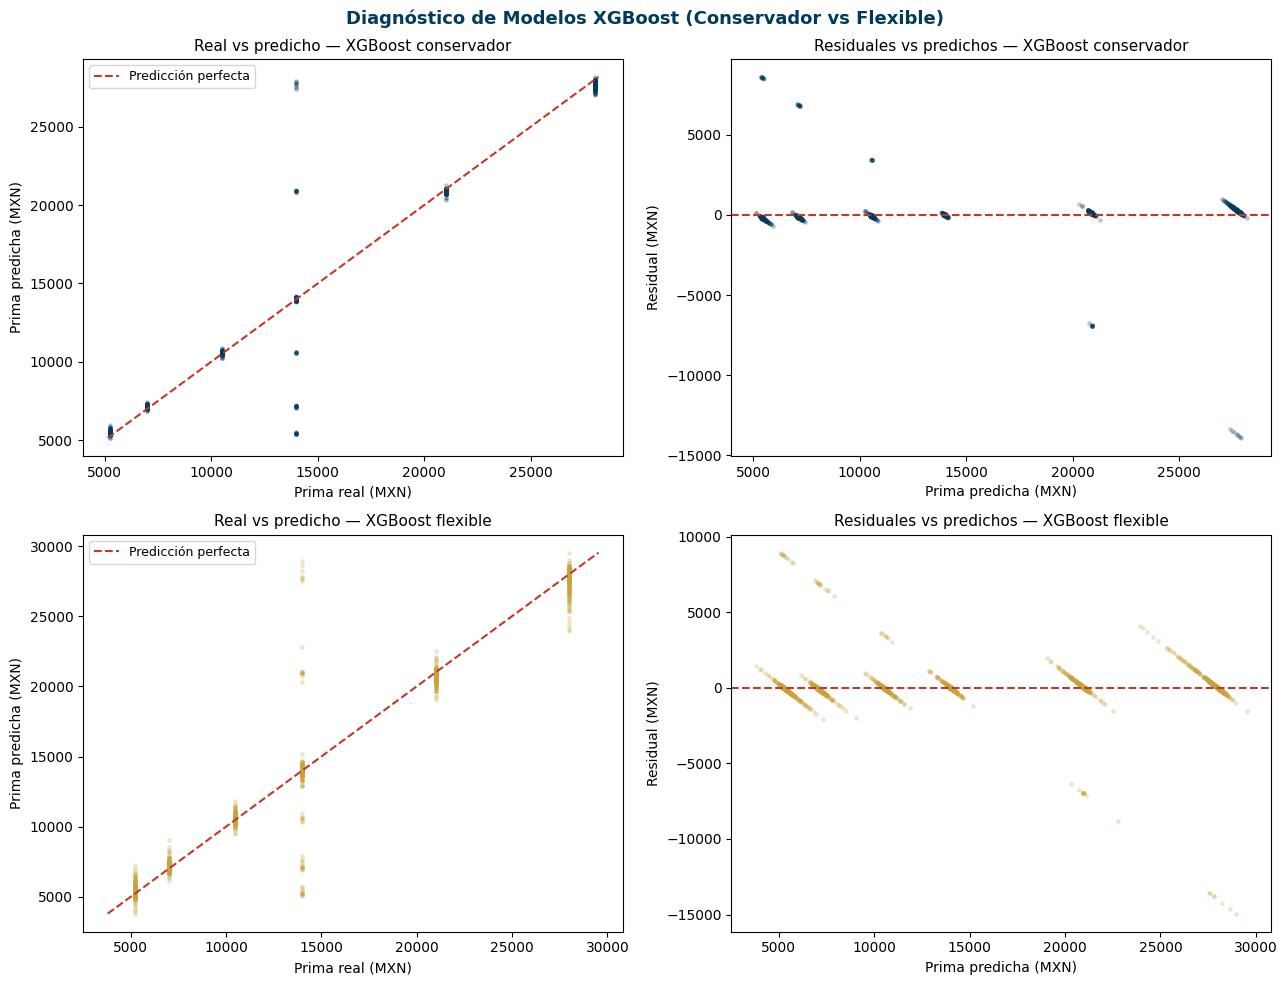

In [24]:
# Graficas

rng = np.random.default_rng(SEED)
idx = rng.choice(len(y_test), size=min(2_000, len(y_test)), replace=False)

# Extraemos los valores reales y las predicciones de ambos modelos
y_r = y_test.iloc[idx].values
y_p_conserv = y_pred_conserv[idx]
y_p_flex = y_pred_flex[idx] # Agregamos las predicciones del modelo flexible

# Creamos una figura más alta con 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- FILA 1: Modelo Conservador (Color NAVY) ---

# 1. Real vs Predicho (Conservador)
axes[0, 0].scatter(y_r, y_p_conserv, alpha=0.2, s=6, color=NAVY)
lims_c = [min(y_r.min(), y_p_conserv.min()), max(y_r.max(), y_p_conserv.max())]
axes[0, 0].plot(lims_c, lims_c, color=RED, linewidth=1.5, linestyle="--",
             label="Predicción perfecta")
axes[0, 0].set_xlabel("Prima real (MXN)")
axes[0, 0].set_ylabel("Prima predicha (MXN)")
axes[0, 0].set_title("Real vs predicho — XGBoost conservador", fontsize=11)
axes[0, 0].legend(fontsize=9)

# 2. Residuales vs Predichos (Conservador)
res_c = y_r - y_p_conserv
axes[0, 1].scatter(y_p_conserv, res_c, alpha=0.2, s=6, color=NAVY)
axes[0, 1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[0, 1].set_xlabel("Prima predicha (MXN)")
axes[0, 1].set_ylabel("Residual (MXN)")
axes[0, 1].set_title("Residuales vs predichos — XGBoost conservador", fontsize=11)


# --- FILA 2: Modelo Flexible (Color GOLD) ---

# 3. Real vs Predicho (Flexible)
axes[1, 0].scatter(y_r, y_p_flex, alpha=0.2, s=6, color=GOLD)
lims_f = [min(y_r.min(), y_p_flex.min()), max(y_r.max(), y_p_flex.max())]
axes[1, 0].plot(lims_f, lims_f, color=RED, linewidth=1.5, linestyle="--",
             label="Predicción perfecta")
axes[1, 0].set_xlabel("Prima real (MXN)")
axes[1, 0].set_ylabel("Prima predicha (MXN)")
axes[1, 0].set_title("Real vs predicho — XGBoost flexible", fontsize=11)
axes[1, 0].legend(fontsize=9)

# 4. Residuales vs Predichos (Flexible)
res_f = y_r - y_p_flex
axes[1, 1].scatter(y_p_flex, res_f, alpha=0.2, s=6, color=GOLD)
axes[1, 1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[1, 1].set_xlabel("Prima predicha (MXN)")
axes[1, 1].set_ylabel("Residual (MXN)")
axes[1, 1].set_title("Residuales vs predichos — XGBoost flexible", fontsize=11)

# Ajuste global del título y los márgenes
fig.suptitle("Diagnóstico de Modelos XGBoost (Conservador vs Flexible)",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

## Red neuronal

In [25]:
# Clasificación de variables

cols_target = ['prima_neta','n_siniestros','monto_pagado']

cols_feature_num = ['edad', 'suma_asegurada']
cols_feature_cat = ['plan','sexo','canal_venta','marca_vehiculo','tipo_vehiculo','modelo_vehiculo','estado','nivel_riesgo']

cols_features = cols_feature_num + cols_feature_cat

cols_pii = df_autos.columns.drop(cols_features).tolist()

X_raw = df_autos[cols_features]

all_columns = len(cols_features) + len(cols_target) + len(cols_pii)
print(f"All Colums: {all_columns}")

All Colums: 57


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED
)
print(f"Train: {X_train.shape[0]:,} obs.  |  Test: {X_test.shape[0]:,} obs.")

Train: 11,801 obs.  |  Test: 2,951 obs.


In [27]:
# Validamos los datos del train

X_train_core, X_val, y_train_core, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=SEED
)
print(f"Split interno de train:")
print(f"  Train core (selección): {X_train_core.shape[0]:,} obs.")
print(f"  Validation (selección): {X_val.shape[0]:,} obs.")
print(f"  Test (evaluación final, intocado): {X_test.shape[0]:,} obs.")
print()
print("Las 3 configuraciones MLP se evaluarán únicamente en validation.")
print("El test set se evaluará UNA sola vez con el modelo final seleccionado.")

Split interno de train:
  Train core (selección): 9,440 obs.
  Validation (selección): 2,361 obs.
  Test (evaluación final, intocado): 2,951 obs.

Las 3 configuraciones MLP se evaluarán únicamente en validation.
El test set se evaluará UNA sola vez con el modelo final seleccionado.


In [28]:
# Preprocesador para MLP

def make_mlp_preprocessor() -> ColumnTransformer:
    """Crea una instancia nueva del preprocesador para MLP y OLS."""
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), cols_feature_num),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
             cols_feature_cat),
        ],
        remainder="drop",
    )

# Verificar dimensión del espacio transformado — instancia de verificación, no reutilizada en pipelines
_pre_check = make_mlp_preprocessor().fit(X_train)
n_features_out = _pre_check.transform(X_train).shape[1]
print(f"Espacio OHE: {n_features_out} features de entrada al MLP")
print(f"  Numéricas (escaladas):   {len(cols_feature_num)}")
print(f"  Categóricas (OHE − 1):  {n_features_out - len(cols_feature_num)}")
n_features_out = _pre_check.transform(X_train).shape[1]
print(f"Espacio OHE: {n_features_out} features de entrada al MLP")
print(f"  Numéricas (escaladas):   {len(cols_feature_num)}")
print(f"  Categóricas (OHE − 1):  {n_features_out - len(cols_feature_num)}")

Espacio OHE: 52 features de entrada al MLP
  Numéricas (escaladas):   2
  Categóricas (OHE − 1):  50
Espacio OHE: 52 features de entrada al MLP
  Numéricas (escaladas):   2
  Categóricas (OHE − 1):  50


In [29]:
# Entrenamiento de MLP con validación interna

configuraciones_val = [
    {"hidden_layer_sizes": (64, 32),  "alpha": 0.001, "label": "(64,32) α=0.001  [base]"},
    {"hidden_layer_sizes": (128, 64), "alpha": 0.001, "label": "(128,64) α=0.001  [más parámetros]"},
    {"hidden_layer_sizes": (64, 32),  "alpha": 0.010, "label": "(64,32) α=0.010  [más regularización]"},
]

print("Evaluación de configuraciones MLP — RMSE en validation:")
print("(Entrenamiento en train_core | Test intocado)")
print()

resultados_val = []
for cfg in configuraciones_val:
    _inner = Pipeline([
        ("preprocessor", make_mlp_preprocessor()),  # instancia fresca — sin estado compartido
        ("mlp", MLPRegressor(
            hidden_layer_sizes=cfg["hidden_layer_sizes"],
            activation="relu", solver="adam",
            alpha=cfg["alpha"], learning_rate_init=0.001,
            max_iter=500, early_stopping=True,
            validation_fraction=0.10, n_iter_no_change=20,
            batch_size="auto", random_state=SEED, verbose=False,
        )),
    ])
    _model = TransformedTargetRegressor(regressor=_inner, transformer=StandardScaler())
    _model.fit(X_train_core, y_train_core)
    _y_val_pred = _model.predict(X_val)
    _rmse_val   = np.sqrt(mean_squared_error(y_val, _y_val_pred))
    _r2_val     = r2_score(y_val, _y_val_pred)
    _n_iter     = _model.regressor_.named_steps["mlp"].n_iter_
    resultados_val.append({
        "label": cfg["label"],
        "hidden_layer_sizes": cfg["hidden_layer_sizes"],
        "alpha": cfg["alpha"],
        "rmse_val": _rmse_val,
        "r2_val": _r2_val,
        "n_iter": _n_iter,
    })
    print(f"  {cfg['label']:<40} RMSE_val={_rmse_val:,.1f}  R²_val={_r2_val:.4f}  épocas={_n_iter}")

# Selección: configuración con menor RMSE de validación
best_val = min(resultados_val, key=lambda d: d["rmse_val"])
print(f"\n→ Configuración seleccionada: {best_val['label']}")
print(f"  RMSE validation = {best_val['rmse_val']:,.1f} MXN  |  R² validation = {best_val['r2_val']:.4f}")

Evaluación de configuraciones MLP — RMSE en validation:
(Entrenamiento en train_core | Test intocado)

  (64,32) α=0.001  [base]                  RMSE_val=1,346.2  R²_val=0.9717  épocas=44
  (128,64) α=0.001  [más parámetros]       RMSE_val=1,313.8  R²_val=0.9731  épocas=32
  (64,32) α=0.010  [más regularización]    RMSE_val=1,346.9  R²_val=0.9717  épocas=44

→ Configuración seleccionada: (128,64) α=0.001  [más parámetros]
  RMSE validation = 1,313.8 MXN  |  R² validation = 0.9731


In [30]:
# Entrenamiento final: configuración seleccionada, reajuste sobre X_train completo (24,000 obs.)
mlp_inner = Pipeline([
    ("preprocessor", make_mlp_preprocessor()),  # instancia fresca — sin estado compartido
    ("mlp", MLPRegressor(
        hidden_layer_sizes=best_val["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=best_val["alpha"],
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,
        batch_size="auto",
        random_state=SEED,
        verbose=False,
    )),
])

# TransformedTargetRegressor escala prima_neta antes de entrenar
mlp_model = TransformedTargetRegressor(
    regressor=mlp_inner,
    transformer=StandardScaler(),
)

print(f"Entrenando MLP con configuración seleccionada: {best_val['label']}")
print(f"Datos de entrenamiento: X_train completo ({X_train.shape[0]:,} obs.)")
mlp_model.fit(X_train, y_train)

# Extraer el MLPRegressor para acceder a loss_curve_ y validation_scores_
mlp_raw = mlp_model.regressor_.named_steps["mlp"]

print(f"\nConvergencia:")
print(f"  Iteraciones realizadas: {mlp_raw.n_iter_}")
print(f"  Iteraciones máximas:    {mlp_raw.max_iter}")
print(f"  early_stopping activo:  {mlp_raw.early_stopping}")
if mlp_raw.n_iter_ < mlp_raw.max_iter:
    print(f"  → Convergió antes del máximo")
else:
    print(f"  → Alcanzó max_iter sin converger completamente")
print(f"  Objetivo final (train interno, escala estandarizada): {mlp_raw.loss_:.6f}")

# Nota sobre early stopping en sklearn MLPRegressor:
# Con early_stopping=True y una tarea de regresión, sklearn monitorea el R² en
# validation_fraction. Se detiene si el R² no mejora en n_iter_no_change iteraciones.
# (No monitorea la "pérdida de validación": validation_scores_ contiene R², no MSE.)
if hasattr(mlp_raw, "validation_scores_") and mlp_raw.validation_scores_ is not None:
    print(f"  R² de validación interna (último): {mlp_raw.validation_scores_[-1]:.4f}")
    print(f"  R² de validación interna (máx):   {max(mlp_raw.validation_scores_):.4f}")

Entrenando MLP con configuración seleccionada: (128,64) α=0.001  [más parámetros]
Datos de entrenamiento: X_train completo (11,801 obs.)

Convergencia:
  Iteraciones realizadas: 30
  Iteraciones máximas:    500
  early_stopping activo:  True
  → Convergió antes del máximo
  Objetivo final (train interno, escala estandarizada): 0.007410
  R² de validación interna (último): 0.9686
  R² de validación interna (máx):   0.9688


Early stopping monitorea R² de validación (no la pérdida de validación).
  R² máximo: 0.9688 (época 12)
  R² final:  0.9686


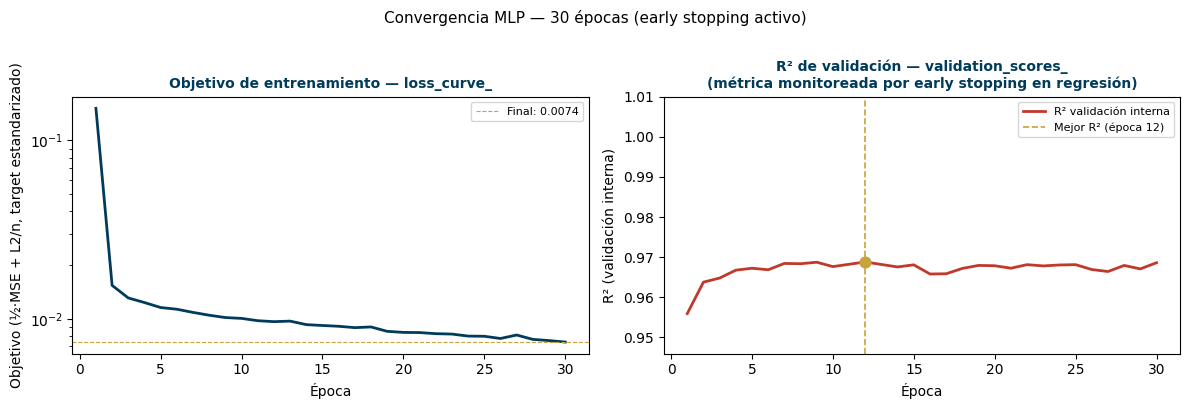


Curva loss_curve_: objetivo ½·MSE + L2/n sobre target estandarizado (NO es RMSE en MXN).
  Épocas: 30  |  Inicial: 0.1513  |  Final: 0.007410
  Reducción: 95.1%


In [31]:
loss_curve   = mlp_raw.loss_curve_
val_scores   = mlp_raw.validation_scores_ if hasattr(mlp_raw, "validation_scores_") else None
n_epochs     = len(loss_curve)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: objetivo de entrenamiento (loss_curve_)
ax1 = axes[0]
ax1.plot(range(1, n_epochs + 1), loss_curve, color=NAVY, linewidth=2.0)
ax1.set_xlabel("Época")
ax1.set_ylabel("Objetivo (½·MSE + L2/n, target estandarizado)")
ax1.set_title("Objetivo de entrenamiento — loss_curve_",
              fontsize=10, color=NAVY, fontweight="bold")
ax1.set_yscale("log")
ax1.axhline(loss_curve[-1], color=GOLD, linewidth=0.8, linestyle="--",
            label=f"Final: {loss_curve[-1]:.4f}")
ax1.legend(fontsize=8)

# Panel 2: R² de validación interna (validation_scores_)
ax2 = axes[1]
if val_scores is not None:
    best_epoch = int(np.argmax(val_scores)) + 1
    ax2.plot(range(1, len(val_scores) + 1), val_scores,
             color=RED, linewidth=2.0, label="R² validación interna")
    ax2.axvline(best_epoch, color=GOLD, linewidth=1.2, linestyle="--",
                label=f"Mejor R² (época {best_epoch})")
    ax2.scatter([best_epoch], [max(val_scores)],
                color=GOLD, s=60, zorder=5)
    ax2.set_xlabel("Época")
    ax2.set_ylabel("R² (validación interna)")
    ax2.set_title("R² de validación — validation_scores_\n"
                  "(métrica monitoreada por early stopping en regresión)",
                  fontsize=10, color=NAVY, fontweight="bold")
    ax2.legend(fontsize=8)
    ax2.set_ylim([max(0, min(val_scores) - 0.01), 1.01])
    print(f"Early stopping monitorea R² de validación (no la pérdida de validación).")
    print(f"  R² máximo: {max(val_scores):.4f} (época {best_epoch})")
    print(f"  R² final:  {val_scores[-1]:.4f}")
else:
    ax2.text(0.5, 0.5, "validation_scores_ no disponible",
             ha="center", va="center", transform=ax2.transAxes)

plt.suptitle(f"Convergencia MLP — {n_epochs} épocas (early stopping activo)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nCurva loss_curve_: objetivo ½·MSE + L2/n sobre target estandarizado (NO es RMSE en MXN).")
print(f"  Épocas: {n_epochs}  |  Inicial: {loss_curve[0]:.4f}  |  Final: {loss_curve[-1]:.6f}")
print(f"  Reducción: {(1 - loss_curve[-1]/loss_curve[0])*100:.1f}%")

In [32]:
# Métricas finales en train y test

y_mlp_train = mlp_model.predict(X_train)
y_mlp_test  = mlp_model.predict(X_test)

rmse_mlp_train = np.sqrt(mean_squared_error(y_train, y_mlp_train))
rmse_mlp_test  = np.sqrt(mean_squared_error(y_test,  y_mlp_test))
mae_mlp_test   = mean_absolute_error(y_test, y_mlp_test)
r2_mlp_train   = r2_score(y_train, y_mlp_train)
r2_mlp_test    = r2_score(y_test,  y_mlp_test)

print("=" * 60)
print("MÉTRICAS FINALES — Test set")
print("(Evaluado una sola vez — no fue usado en selección)")
print("=" * 60)
print()
header = f"{'Modelo':<35} {'RMSE test':>10} {'MAE test':>10} {'R² test':>8} {'R² train':>9}"
print(header)
print("-" * len(header))

mlp_nombre = f"MLP {best_val['label']}"
print(f"{mlp_nombre:<35} {rmse_mlp_test:>10,.1f} {mae_mlp_test:>10,.1f} "
      f"{r2_mlp_test:>8.4f} {r2_mlp_train:>9.4f}")
print()
print(f"Configuración MLP seleccionada: {best_val['label']}")
print(f"  RMSE_validation = {best_val['rmse_val']:,.1f} MXN  |  R²_validation = {best_val['r2_val']:.4f}")

MÉTRICAS FINALES — Test set
(Evaluado una sola vez — no fue usado en selección)

Modelo                               RMSE test   MAE test  R² test  R² train
----------------------------------------------------------------------------
MLP (128,64) α=0.001  [más parámetros]    1,496.2      621.8   0.9634    0.9806

Configuración MLP seleccionada: (128,64) α=0.001  [más parámetros]
  RMSE_validation = 1,313.8 MXN  |  R²_validation = 0.9731


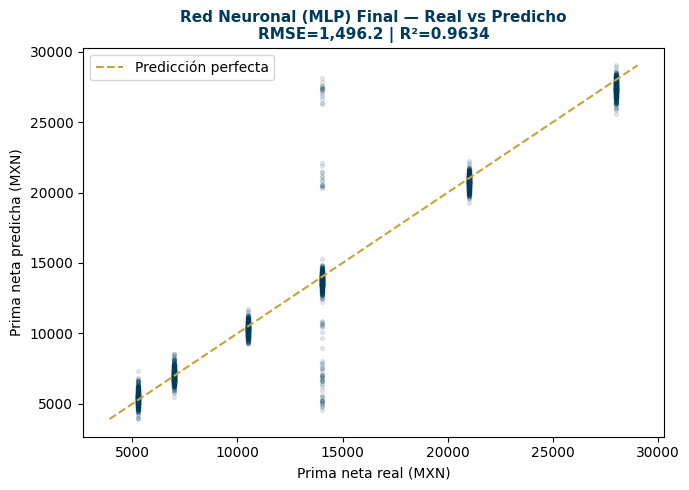

In [33]:
import matplotlib.pyplot as plt

# ── GRÁFICA DEL MODELO FINAL (MLP) ──────────────────────────────────
# Usamos el modelo que ya tienes entrenado en tu entorno
y_mlp_test = mlp_model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y_test, y_mlp_test, alpha=0.1, s=8, color=NAVY)
lim = [min(y_test.min(), y_mlp_test.min()), max(y_test.max(), y_mlp_test.max())]
ax.plot(lim, lim, "--", color=GOLD, linewidth=1.5, label="Predicción perfecta")

ax.set_xlabel("Prima neta real (MXN)")
ax.set_ylabel("Prima neta predicha (MXN)")
ax.set_title(f"Red Neuronal (MLP) Final — Real vs Predicho\nRMSE={rmse_mlp_test:,.1f} | R²={r2_mlp_test:.4f}",
             fontsize=11, color=NAVY, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

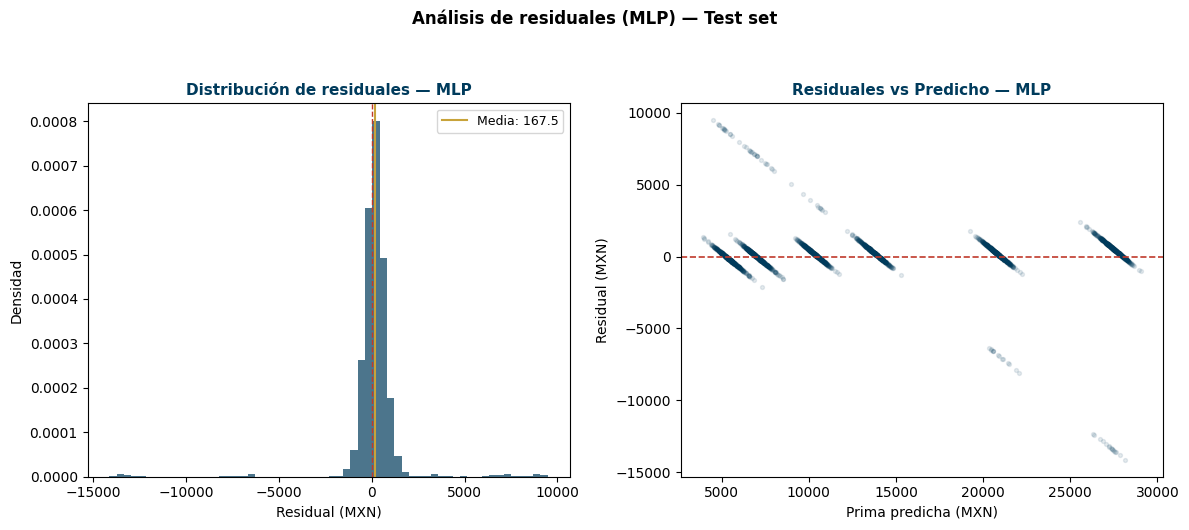

DIAGNÓSTICO CUANTITATIVO DE RESIDUALES (MLP):
Media de errores: +167.49 MXN | Desviación estándar: 1,486.8 MXN
Correlación (predicción, |error|) = 0.079
Dispersión (Std) por decil de predicción: 232–2,513 MXN
------------------------------------------------------------
Nota: Un valor cercano a 0 en la correlación sugiere estabilidad en la varianza.


In [34]:
# ── ANÁLISIS DE RESIDUALES  ───
residuales_mlp = y_test.values - y_mlp_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Distribución de residuales
axes[0].hist(residuales_mlp, bins=60, color=NAVY, alpha=0.7, density=True)
axes[0].axvline(0, color=RED, linewidth=1.0, linestyle="--")
axes[0].axvline(residuales_mlp.mean(), color=GOLD, linewidth=1.5,
                linestyle="-", label=f"Media: {residuales_mlp.mean():.1f}")
axes[0].set_xlabel("Residual (MXN)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución de residuales — MLP", fontsize=11, color=NAVY, fontweight="bold")
axes[0].legend(fontsize=9)

# 2. Residuales vs predicho (Heterocedasticidad)
axes[1].scatter(y_mlp_test, residuales_mlp, alpha=0.1, s=8, color=NAVY)
axes[1].axhline(0, color=RED, linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Prima predicha (MXN)")
axes[1].set_ylabel("Residual (MXN)")
axes[1].set_title("Residuales vs Predicho — MLP", fontsize=11, color=NAVY, fontweight="bold")

plt.suptitle("Análisis de residuales (MLP) — Test set", fontsize=12, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

# ── DIAGNÓSTICO CUANTITATIVO (SOLO MLP) ────────────────────────────────
corr_pred_abs_resid = float(np.corrcoef(y_mlp_test, np.abs(residuales_mlp))[0, 1])
_decile_idx = pd.qcut(y_mlp_test, 10, labels=False, duplicates="drop")
_decile_std = pd.Series(residuales_mlp).groupby(_decile_idx).std()
resid_std_decile_min = float(_decile_std.min())
resid_std_decile_max = float(_decile_std.max())

print("DIAGNÓSTICO CUANTITATIVO DE RESIDUALES (MLP):")
print(f"Media de errores: {residuales_mlp.mean():+.2f} MXN | Desviación estándar: {residuales_mlp.std():,.1f} MXN")
print(f"Correlación (predicción, |error|) = {corr_pred_abs_resid:.3f}")
print(f"Dispersión (Std) por decil de predicción: {resid_std_decile_min:,.0f}–{resid_std_decile_max:,.0f} MXN")
print("-" * 60)
print("Nota: Un valor cercano a 0 en la correlación sugiere estabilidad en la varianza.")

In [35]:
# Tabla resumen de resultados de validation
print("Tabla de selección — RMSE en validation (NO en test):")
print()
print(f"{'Configuración':<40} {'RMSE_val':>10} {'R²_val':>8} {'Épocas':>7}")
print("-" * 68)
for res in resultados_val:
    marca = " ← seleccionada" if res["label"] == best_val["label"] else ""
    print(f"  {res['label']:<38} {res['rmse_val']:>10,.1f} {res['r2_val']:>8.4f} {res['n_iter']:>7}{marca}")
print()
print(f"Modelo final (reentrenado sobre X_train completo, 24,000 obs.):")
print(f"  RMSE_test  = {rmse_mlp_test:,.1f} MXN")
print(f"  R²_test    = {r2_mlp_test:.4f}")
print()
print("Interpretación:")
print("• Las métricas de validation permiten seleccionar sin contaminar el test.")
print("• El reentrenamiento sobre el train completo puede cambiar las métricas")
print("  respecto a la evaluación en validation (más datos → puede mejorar o variar).")
print("• El RMSE_test es la estimación definitiva del desempeño sobre datos no vistos.")

Tabla de selección — RMSE en validation (NO en test):

Configuración                              RMSE_val   R²_val  Épocas
--------------------------------------------------------------------
  (64,32) α=0.001  [base]                   1,346.2   0.9717      44
  (128,64) α=0.001  [más parámetros]        1,313.8   0.9731      32 ← seleccionada
  (64,32) α=0.010  [más regularización]     1,346.9   0.9717      44

Modelo final (reentrenado sobre X_train completo, 24,000 obs.):
  RMSE_test  = 1,496.2 MXN
  R²_test    = 0.9634

Interpretación:
• Las métricas de validation permiten seleccionar sin contaminar el test.
• El reentrenamiento sobre el train completo puede cambiar las métricas
  respecto a la evaluación en validation (más datos → puede mejorar o variar).
• El RMSE_test es la estimación definitiva del desempeño sobre datos no vistos.


## Random Forest

In [36]:
# Clasificación de variables

cols_target = ['prima_neta','n_siniestros','monto_pagado']

cols_feature_num = ['edad', 'suma_asegurada']
cols_feature_cat = ['plan','sexo','canal_venta','marca_vehiculo','tipo_vehiculo','modelo_vehiculo','estado','nivel_riesgo']
cols_features = cols_feature_num + cols_feature_cat

cols_pii = df_autos.columns.drop(cols_features).tolist()

all_columns = len(cols_features) + len(cols_target) + len(cols_pii)

print(f"All Colums: {all_columns}")

All Colums: 57


In [37]:
## Preparación del conjunto de datos

TARGET_COLUMNS = ['prima_neta','n_siniestros','monto_pagado']

TARGET = "prima_neta"
SEED  = 20260618
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

X_raw = df_autos[cols_features]
y     = df_autos[TARGET]

# Codificación one-hot de categóricas (drop_first=True evita multicolinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

# Split 80/20 en train/test; random_state fija una partición reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Verificar que no hay targets en X
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} está en X"
print("✓ Ningún target en X")
assert "id_poliza_sin" not in X.columns
print("✓ id_poliza_sin excluido")

Features tras OHE: 52 columnas
Ejemplos de nuevas columnas: ['edad', 'suma_asegurada', 'modelo_vehiculo', 'plan_20 anios', 'plan_Amplia'] ...

Train: 11,801 filas | Test: 2,951 filas
✓ Ningún target en X
✓ id_poliza_sin excluido


In [38]:
rf = RandomForestRegressor(
    n_estimators=150,
    max_features=1.0,          # todas las features en cada split (bagging pleno)
    max_depth=None,            # árboles completos (la varianza la controla el promedio)
    min_samples_leaf=5,
    oob_score=True,            # error out-of-bag como estimación de generalización
    n_jobs=-1,
    random_state=SEED,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest (n=150, max_features=1.0): RMSE={rmse_rf:,.0f} MXN | MAE={mae_rf:,.0f} | R²={r2_rf:.4f}")
print(f"OOB R² (estimación sin test set): {rf.oob_score_:.4f}")

Random Forest (n=150, max_features=1.0): RMSE=1,432 MXN | MAE=352 | R²=0.9664
OOB R² (estimación sin test set): 0.9790


In [39]:
# Comparación: sqrt vs p/3 vs 1.0
p = X_train.shape[1]
configs = {
    "sqrt":      "sqrt",
    f"p/3 ≈{p//3}": p // 3,
    "1.0 (todas)": 1.0,
}

print(f"{'max_features':20s}  {'RMSE test (MXN)':>16s}  {'R² test':>8s}")
print("-" * 50)
for label, mf in configs.items():
    m_tmp = RandomForestRegressor(
        n_estimators=150, max_features=mf,
        min_samples_leaf=5, n_jobs=-1, random_state=SEED
    )
    m_tmp.fit(X_train, y_train)
    r = np.sqrt(mean_squared_error(y_test, m_tmp.predict(X_test)))
    r2 = r2_score(y_test, m_tmp.predict(X_test))
    print(f"{label:20s}  {r:>16,.0f}  {r2:>8.4f}")

print()
print("Conclusión: con pocas features dominantes, max_features=1.0 reduce el RMSE")
print("porque garantiza que suma_asegurada y plan_Plus siempre están disponibles en cada split.")
print("sqrt es útil en datasets con muchas features irrelevantes (mayor decorrelación necesaria).")

max_features           RMSE test (MXN)   R² test
--------------------------------------------------
sqrt                             2,113    0.9269
p/3 ≈17                          1,438    0.9662
1.0 (todas)                      1,432    0.9664

Conclusión: con pocas features dominantes, max_features=1.0 reduce el RMSE
porque garantiza que suma_asegurada y plan_Plus siempre están disponibles en cada split.
sqrt es útil en datasets con muchas features irrelevantes (mayor decorrelación necesaria).


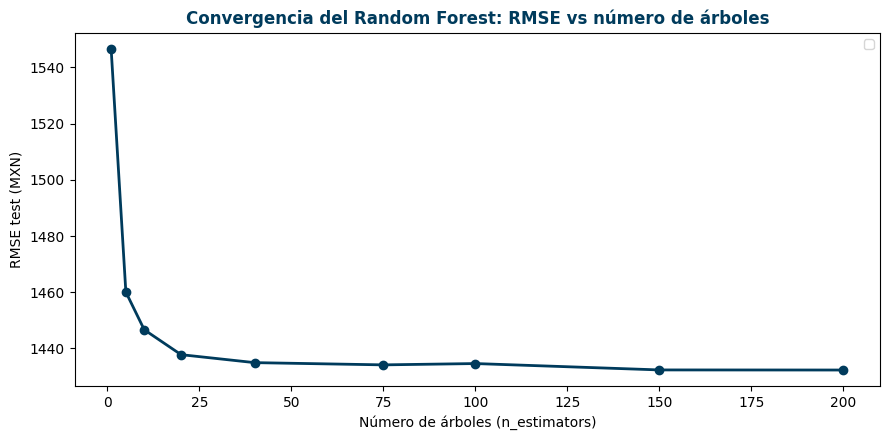

Observación: a partir de ~50 árboles, el RMSE se estabiliza.
Agregar más árboles tiende a estabilizar el error; pequeñas fluctuaciones pueden ocurrir.


In [40]:
n_tree_range = [1, 5, 10, 20, 40, 75, 100, 150, 200]
rmse_by_n    = []

for n_t in n_tree_range:
    m = RandomForestRegressor(
        n_estimators=n_t, max_features=1.0,
        min_samples_leaf=5, n_jobs=-1, random_state=SEED
    )
    m.fit(X_train, y_train)
    rmse_by_n.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(n_tree_range, rmse_by_n, color=NAVY, linewidth=2, marker="o", ms=6)
ax.set_xlabel("Número de árboles (n_estimators)")
ax.set_ylabel("RMSE test (MXN)")
ax.set_title("Convergencia del Random Forest: RMSE vs número de árboles",
             fontsize=12, fontweight="bold", color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Observación: a partir de ~50 árboles, el RMSE se estabiliza.")
print("Agregar más árboles tiende a estabilizar el error; pequeñas fluctuaciones pueden ocurrir.")

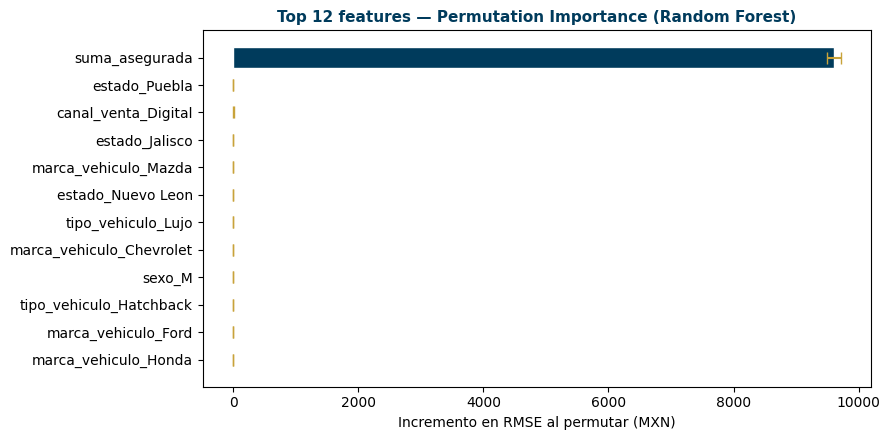


Top 5 por permutation importance:
             Feature     PI_mean
      suma_asegurada 9600.910252
       estado_Puebla    3.126740
 canal_venta_Digital    2.009849
      estado_Jalisco    1.724219
marca_vehiculo_Mazda    1.453490


In [41]:
# Permutation importance sobre el test set (10 repeticiones para estabilidad)
perm_result = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10, random_state=SEED, n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

pi_df = pd.DataFrame({
    "Feature":     X_test.columns,
    "PI_mean":     perm_result.importances_mean,
    "PI_std":      perm_result.importances_std,
}).sort_values("PI_mean", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(pi_df["Feature"], pi_df["PI_mean"],
        xerr=pi_df["PI_std"],
        color=NAVY, edgecolor="white", error_kw={"ecolor": GOLD, "capsize": 4})
ax.set_xlabel("Incremento en RMSE al permutar (MXN)")
ax.set_title("Top 12 features — Permutation Importance (Random Forest)",
             fontsize=11, fontweight="bold", color=NAVY)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 por permutation importance:")
print(pi_df[["Feature", "PI_mean"]].head(5).to_string(index=False))

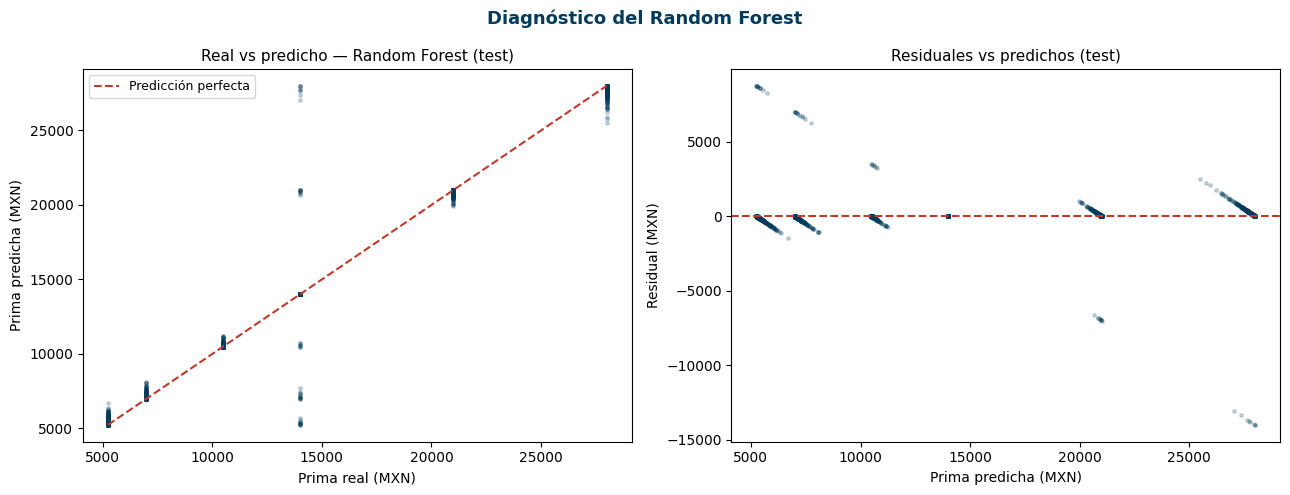

In [42]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(y_test), size=min(2_000, len(y_test)), replace=False)

y_r = y_test.iloc[idx].values
y_p = y_pred_rf[idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_r, y_p, alpha=0.2, s=6, color=NAVY)
lims = [min(y_r.min(), y_p.min()), max(y_r.max(), y_p.max())]
axes[0].plot(lims, lims, color=RED, linewidth=1.5, linestyle="--",
             label="Predicción perfecta")
axes[0].set_xlabel("Prima real (MXN)")
axes[0].set_ylabel("Prima predicha (MXN)")
axes[0].set_title("Real vs predicho — Random Forest (test)", fontsize=11)
axes[0].legend(fontsize=9)

res = y_r - y_p
axes[1].scatter(y_p, res, alpha=0.2, s=6, color=NAVY)
axes[1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Prima predicha (MXN)")
axes[1].set_ylabel("Residual (MXN)")
axes[1].set_title("Residuales vs predichos (test)", fontsize=11)

fig.suptitle("Diagnóstico del Random Forest",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

# Modelos para estimar la variable ocurrencia_siniestro

## Support Vector Machine (Variable Binaria)

In [43]:
#Definición del Target y revisión

target_binaria = "ocurrencia_siniestro"
df_autos['ocurrencia_siniestro'] = (df_autos['n_siniestros'] > 0).astype(int)

# Distribución de la clase
vc = df_autos[target_binaria].value_counts(normalize=True) * 100
print("Distribución de siniestros:")
print(f"  0 (sin siniestro): {vc.get(0, 0):.1f}%")
print(f"  1 (con siniestro): {vc.get(1, 0):.1f}%")

# Verificar la definición: n_siniestros = int(n_siniestros > 0)
computed = (df_autos["n_siniestros"] > 0).astype(int)
assert (computed == df_autos[target_binaria]).all(), "El target no coincide con la definición esperada"
print("\n✓ n_siniestros == int(n_siniestros > 0) verificado")

Distribución de siniestros:
  0 (sin siniestro): 70.0%
  1 (con siniestro): 30.0%

✓ n_siniestros == int(n_siniestros > 0) verificado


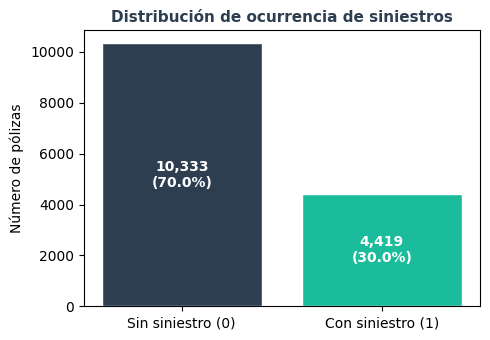

In [44]:
# Gráfica de la distribución de pólizas con y sin siniestros, en la base de Autos

colores_base = ["#2C3E50", "#1ABC9C", "#95A5A6", "#E67E22", "#34495E"]
COLOR_SIN = colores_base[0] # #2C3E50
COLOR_CON = colores_base[1] # #1ABC9C

# Preparación de datos
N = len(df_autos)
conteos = df_autos[target_binaria].value_counts().sort_index()
colores = [COLOR_SIN, COLOR_CON]

# Gráfica
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.bar(["Sin siniestro (0)", "Con siniestro (1)"],
       conteos.values, color=colores, edgecolor="white")

# Etiquetas
#offset = N * 0.02
for i, v in enumerate(conteos.values):
    ax.text(i, v /2, f"{v:,}\n({(v/N)*100:.1f}%)",
            ha="center", va="center", fontsize=10, fontweight='bold', color='white')
# Estilos
ax.set_ylabel("Número de pólizas")
ax.set_title("Distribución de ocurrencia de siniestros", fontsize=11, color=COLOR_SIN, fontweight='bold')

plt.tight_layout()
plt.show()

In [45]:
#Estas variables las definimos en el equipo comolas relevantes a utilizar en el modelo.

# Variables predictoras
FEATURE_COLUMNS = ['edad', 'plan', 'sexo', 'canal_venta', 'marca_vehiculo',
                   'tipo_vehiculo', 'modelo_vehiculo', 'estado']

# Definir columnas numéricas y categóricas dentro de FEATURE_COLUMNS
NUMERIC_FEATURES = ["edad"]
CAT_FEATURES = ['plan', 'sexo', 'canal_venta', 'marca_vehiculo',
                   'tipo_vehiculo', 'modelo_vehiculo', 'estado']

TARGET = "ocurrencia_siniestro"

X_raw = df_autos[FEATURE_COLUMNS]
y     = df_autos[TARGET]

# Verificaciones de leakage
for t in TARGET_COLUMNS:
    assert t not in X_raw.columns, f"Leakage: {t} en X_raw"
assert "id_poliza_sin" not in X_raw.columns
print("✓ Sin leakage de targets ni id_poliza_sin")
print(f"  Features numéricas : {len(NUMERIC_FEATURES)}")
print(f"  Features categóricas: {len(CAT_FEATURES)}")
print(f"  Total              : {len(FEATURE_COLUMNS)}")

# ── Split principal 80/20 estratificado ────────────────────────────────────
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"\nTrain completo: {X_train_all.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Proporción clase 1 — train: {y_train_all.mean():.4f}  |  test: {y_test.mean():.4f}")

# ── Submuestra estratificada de 5,000 para experimentos SVM ──────────────
N_SUB = 10_000
X_train, _, y_train, _ = train_test_split(
    X_train_all, y_train_all,
    train_size=N_SUB,
    random_state=SEED,
    stratify=y_train_all,
)
print(f"\nSubmuestra SVM: {X_train.shape[0]:,} obs. (estratificada de train)")
print(f"Proporción clase 1 en submuestra: {y_train.mean():.4f}")

✓ Sin leakage de targets ni id_poliza_sin
  Features numéricas : 1
  Features categóricas: 7
  Total              : 8

Train completo: 11,801  |  Test: 2,951
Proporción clase 1 — train: 0.2996  |  test: 0.2996

Submuestra SVM: 10,000 obs. (estratificada de train)
Proporción clase 1 en submuestra: 0.2996


In [46]:
# Preprocesador para SVM (logístico, SVM lineal, SVM RBF): OHE completo (drop=None)
#
# drop="first" introduce una geometría arbitraria para métodos basados en distancia
# (kernel RBF): la categoría de referencia queda a distancia 1 de cualquier otra,
# mientras dos categorías no-referencia quedan a distancia √2. OHE completo evita
# privilegiar una categoría de referencia; no garantiza por sí solo mejor AUC, es una
# corrección de representación. Cada pipeline recibe una instancia FRESCA de esta
# factory — un ColumnTransformer ya ajustado por un pipeline no debe reutilizarse en otro.
def make_svm_preprocessor() -> ColumnTransformer:
    """Crea una instancia nueva del preprocesador para los modelos del bloque SVM."""
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False),
             CAT_FEATURES),
        ],
        remainder="drop",
    )

# Dimensión del espacio transformado — instancia de verificación, no reutilizada en pipelines
_pre_check = make_svm_preprocessor().fit(X_train)
X_tr_transformed = _pre_check.transform(X_train)
print(f"Dimensión del espacio OHE: {X_tr_transformed.shape[1]} features")
print(f"  Numéricas (escaladas):      {len([NUMERIC_FEATURES])}")
print(f"  Categóricas (OHE completo): {X_tr_transformed.shape[1] - len([NUMERIC_FEATURES])}")

Dimensión del espacio OHE: 56 features
  Numéricas (escaladas):      1
  Categóricas (OHE completo): 55


In [47]:
# SVM Lineal
pipeline_svm_lin = Pipeline([
    ("preprocessor", make_svm_preprocessor()),  # instancia fresca — sin estado compartido
    ("svm", SVC(
        kernel="linear",
        C=1.0,
        decision_function_shape="ovr",
        random_state=SEED,
        class_weight="balanced",
    )),
])

print("Entrenando SVM lineal (kernel=linear, C=1.0)...")
t0 = time.time()
pipeline_svm_lin.fit(X_train, y_train)
t_lin = time.time() - t0
print(f"  Tiempo de entrenamiento: {t_lin:.1f} s")

y_svm_lin_pred  = pipeline_svm_lin.predict(X_test)
y_svm_lin_score = pipeline_svm_lin.decision_function(X_test)

auc_lin = roc_auc_score(y_test, y_svm_lin_score)
ap_lin  = average_precision_score(y_test, y_svm_lin_score)
ba_lin  = balanced_accuracy_score(y_test, y_svm_lin_pred)
f1_lin  = f1_score(y_test, y_svm_lin_pred)
sv_lin  = pipeline_svm_lin.named_steps["svm"].n_support_

print(f"\nSVM Lineal (n_train=5,000):")
print(f"  ROC-AUC:           {auc_lin:.4f}")
print(f"  Average Precision:  {ap_lin:.4f}")
print(f"  Balanced Accuracy:  {ba_lin:.4f}")
print(f"  F1 (score=0):       {f1_lin:.4f}")
print(f"  Vectores de soporte: {sv_lin.sum():,} ({sv_lin[0]:,} clase 0, {sv_lin[1]:,} clase 1)")
print(f"  Proporción SV: {sv_lin.sum()/N_SUB:.3f} del total de entrenamiento")
print()
print("Nota: predict() de SVC equivale a sign(decision_function), umbral en score=0.")

Entrenando SVM lineal (kernel=linear, C=1.0)...
  Tiempo de entrenamiento: 12.1 s

SVM Lineal (n_train=5,000):
  ROC-AUC:           0.4980
  Average Precision:  0.3004
  Balanced Accuracy:  0.5004
  F1 (score=0):       0.3392
  Vectores de soporte: 9,681 (6,779 clase 0, 2,902 clase 1)
  Proporción SV: 0.968 del total de entrenamiento

Nota: predict() de SVC equivale a sign(decision_function), umbral en score=0.


In [48]:
param_grid = [
   {
       'svm__kernel': ['linear'],
       'svm__C': [0.1, 1.0, 10.0]
   },
   {
       'svm__kernel': ['rbf'],
       'svm__C': [0.1, 1.0, 10.0],
       'svm__gamma': ['scale', 0.1, 0.01]
   }
]

pipeline_svm_linear_cv = Pipeline([
   ("preprocessor", make_svm_preprocessor()),
   ("svm", SVC(
       kernel="linear",
      decision_function_shape="ovr",
       random_state=SEED,
       class_weight="balanced"
   )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
   pipeline_svm_linear_cv,
   param_grid,
   cv=cv,
   scoring="roc_auc",
  n_jobs=1,
   verbose=0,
)

n_combinations = sum(len(d.get('svm__C', [])) * len(d.get('svm__gamma', [1])) for d in param_grid)
print(f"GridSearchCV: {n_combinations} combinaciones × 5-fold CV (StratifiedKFold)...")

t0 = time.time()
grid_search.fit(X_train, y_train)
t_grid = time.time() - t0
print(f"  Tiempo total de búsqueda: {t_grid:.1f} s")

best_params = grid_search.best_params_
best_cv_auc = grid_search.best_score_
print(f"\nMejores hiperparámetros (CV, no test):")
print(f"  C = {best_params['svm__C']}")
if 'svm__gamma' in best_params:
   print(f"  gamma = {best_params['svm__gamma']}")
print(f"  ROC-AUC CV (media 5-fold StratifiedKFold): {best_cv_auc:.4f}")

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_table = cv_results[["param_svm__kernel", "param_svm__C", "param_svm__gamma",
                      "mean_test_score", "std_test_score"]].copy()
cv_table.columns = ["Kernel", "C", "gamma", "AUC_media", "AUC_std"]
cv_table["gamma"] = cv_table["gamma"].fillna("-")
cv_table = cv_table.sort_values("AUC_media", ascending=False)
print("\nResultados de CV (ordenados por AUC):")
print(cv_table.to_string(index=False, float_format="{:.4f}".format))

GridSearchCV: 12 combinaciones × 5-fold CV (StratifiedKFold)...
  Tiempo total de búsqueda: 502.9 s

Mejores hiperparámetros (CV, no test):
  C = 0.1
  gamma = 0.01
  ROC-AUC CV (media 5-fold StratifiedKFold): 0.5071

Resultados de CV (ordenados por AUC):
Kernel       C  gamma  AUC_media  AUC_std
   rbf  0.1000 0.0100     0.5071   0.0084
   rbf  1.0000 0.0100     0.5068   0.0050
   rbf  0.1000 0.1000     0.5055   0.0048
linear  1.0000      -     0.5054   0.0049
linear  0.1000      -     0.5053   0.0043
linear 10.0000      -     0.5049   0.0045
   rbf  0.1000  scale     0.5044   0.0048
   rbf 10.0000 0.0100     0.5021   0.0054
   rbf  1.0000  scale     0.4909   0.0084
   rbf  1.0000 0.1000     0.4908   0.0077
   rbf 10.0000 0.1000     0.4886   0.0102
   rbf 10.0000  scale     0.4885   0.0101


In [49]:
#Mejor modelo SVM RBF
pipeline_svm_rbf = grid_search.best_estimator_

#Ya está ajustado sobre X_train (grid_search.refit=True por defecto)
print("Usando best_estimator_ (ya ajustado sobre X_train).")

y_svm_rbf_pred  = pipeline_svm_rbf.predict(X_test)
y_svm_rbf_score = pipeline_svm_rbf.decision_function(X_test)

auc_rbf = roc_auc_score(y_test, y_svm_rbf_score)
ap_rbf  = average_precision_score(y_test, y_svm_rbf_score)
ba_rbf  = balanced_accuracy_score(y_test, y_svm_rbf_pred)
f1_rbf  = f1_score(y_test, y_svm_rbf_pred)
sv_rbf  = pipeline_svm_rbf.named_steps["svm"].n_support_

print(f"\nSVM RBF (C={best_params['svm__C']}, gamma={best_params['svm__gamma']}):")
print(f"  ROC-AUC:           {auc_rbf:.4f}")
print(f"  Average Precision:  {ap_rbf:.4f}")
print(f"  Balanced Accuracy:  {ba_rbf:.4f}")
print(f"  F1 (score=0):       {f1_rbf:.4f}")
print(f"  Vectores de soporte: {sv_rbf.sum():,} ({sv_rbf[0]:,} clase 0, {sv_rbf[1]:,} clase 1)")
print(f"  Proporción SV: {sv_rbf.sum()/N_SUB:.3f} del total de entrenamiento")
print()
print("Nota: predict() de SVC usa sign(decision_function), umbral en score=0.")

Usando best_estimator_ (ya ajustado sobre X_train).

SVM RBF (C=0.1, gamma=0.01):
  ROC-AUC:           0.4985
  Average Precision:  0.3020
  Balanced Accuracy:  0.4980
  F1 (score=0):       0.2895
  Vectores de soporte: 10,000 (7,004 clase 0, 2,996 clase 1)
  Proporción SV: 1.000 del total de entrenamiento

Nota: predict() de SVC usa sign(decision_function), umbral en score=0.


In [50]:
#Tabla de comparación
modelos = [
   ("SVM lineal (C=1.0)",    y_svm_lin_pred, y_svm_lin_score),
   (f"SVM RBF (C={best_params['svm__C']}, γ={best_params['svm__gamma']})",
    y_svm_rbf_pred, y_svm_rbf_score),
]

rows = []
for nombre, y_pred, y_score in modelos:
    #El umbral de clasificación depende del modelo:
    #- Logístico: predict() usa probabilidad 0.5 → equivalente a score=0
    #- SVM lineal/RBF: predict() usa sign(decision_function) → score=0
   rows.append({
       "Modelo":              nombre,
       "ROC-AUC":             f"{roc_auc_score(y_test, y_score):.4f}",
       "Avg Precision":       f"{average_precision_score(y_test, y_score):.4f}",
       "Balanced Acc":        f"{balanced_accuracy_score(y_test, y_pred):.4f}",
       "F1 (score=0)":        f"{f1_score(y_test, y_pred):.4f}",
       "Precision":           f"{precision_score(y_test, y_pred):.4f}",
       "Recall":              f"{recall_score(y_test, y_pred):.4f}",
   })

result_df = pd.DataFrame(rows)
print("Comparación de modelos — Test set (n=6,000):")
print(result_df.to_string(index=False))
print()
print("Umbral de clasificación por modelo:")
print("  SVM:       predict() = sign(decision_function)  → umbral en score = 0")

Comparación de modelos — Test set (n=6,000):
                 Modelo ROC-AUC Avg Precision Balanced Acc F1 (score=0) Precision Recall
     SVM lineal (C=1.0)  0.4980        0.3004       0.5004       0.3392    0.3000 0.3903
SVM RBF (C=0.1, γ=0.01)  0.4985        0.3020       0.4980       0.2895    0.2966 0.2828

Umbral de clasificación por modelo:
  SVM:       predict() = sign(decision_function)  → umbral en score = 0


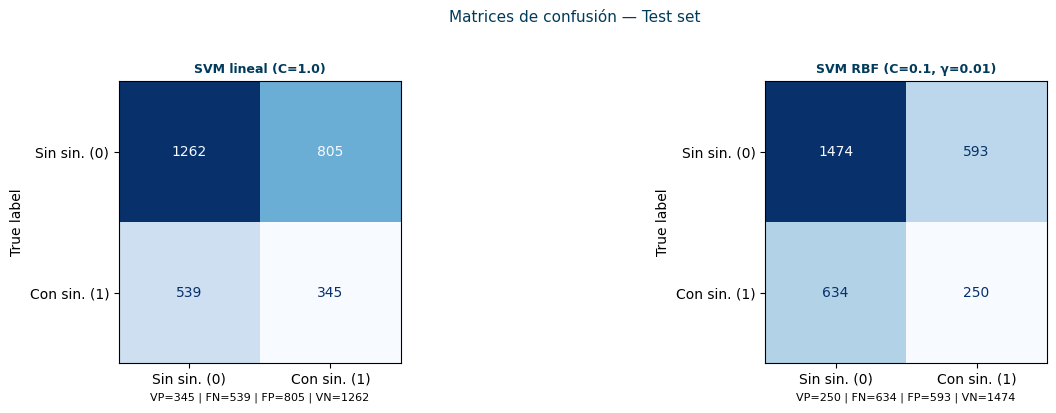

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (nombre, y_pred, _) in zip(axes, modelos):
   cm = confusion_matrix(y_test, y_pred)
   disp = ConfusionMatrixDisplay(
       confusion_matrix=cm,
       display_labels=["Sin sin. (0)", "Con sin. (1)"],
   )
   disp.plot(ax=ax, colorbar=False, cmap="Blues")
   ax.set_title(nombre, fontsize=9, color=NAVY, fontweight="bold")
   tn, fp, fn, tp = cm.ravel()
   ax.set_xlabel(f"VP={tp} | FN={fn} | FP={fp} | VN={tn}", fontsize=8)

plt.suptitle("Matrices de confusión — Test set", fontsize=11, color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

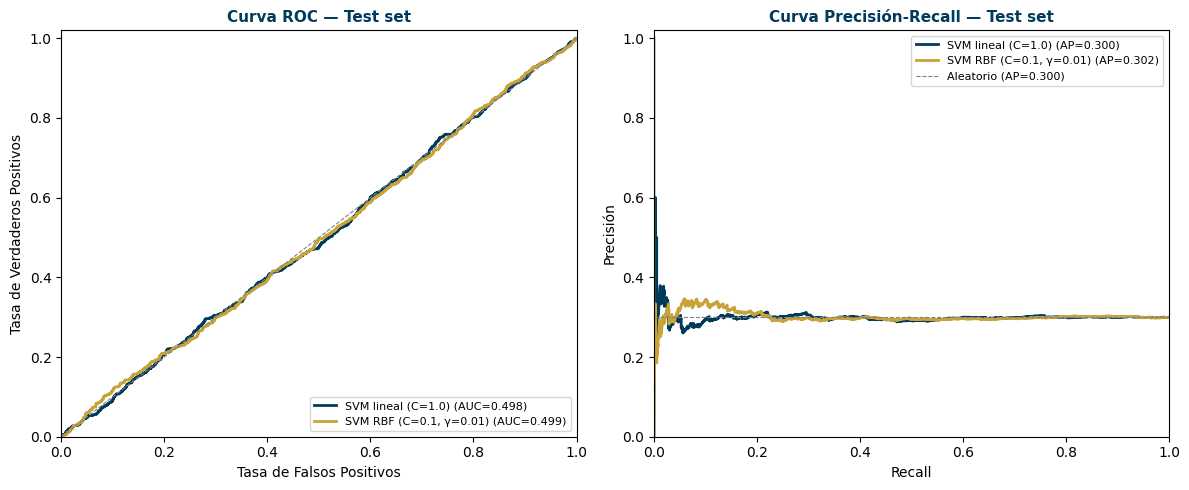

In [52]:
colores_modelos = [NAVY, GOLD]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for (nombre, y_pred, y_score), color in zip(modelos, colores_modelos):
   # Curva ROC
   fpr, tpr, _ = roc_curve(y_test, y_score)
   auc = roc_auc_score(y_test, y_score)
   ax1.plot(fpr, tpr, color=color, linewidth=2.0,
            label=f"{nombre} (AUC={auc:.3f})")

    # Curva PR
   prec, rec, _ = precision_recall_curve(y_test, y_score)
   ap = average_precision_score(y_test, y_score)
   ax2.plot(rec, prec, color=color, linewidth=2.0,
            label=f"{nombre} (AP={ap:.3f})")

ax1.plot([0, 1], [0, 1], "--", color="gray", linewidth=0.8)
ax1.set_xlabel("Tasa de Falsos Positivos")
ax1.set_ylabel("Tasa de Verdaderos Positivos")
ax1.set_title("Curva ROC — Test set", fontsize=11, color=NAVY, fontweight="bold")
ax1.legend(fontsize=8, loc="lower right")
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])

base_ap = y_test.mean()  # AP del clasificador aleatorio
ax2.axhline(base_ap, color="gray", linewidth=0.8, linestyle="--",
           label=f"Aleatorio (AP={base_ap:.3f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precisión")
ax2.set_title("Curva Precisión-Recall — Test set", fontsize=11, color=NAVY, fontweight="bold")
ax2.legend(fontsize=8, loc="upper right")
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

## Random Forest (Variable Binaria)

In [53]:
#Estas variables las definimos en el equipo comolas relevantes a utilizar en el modelo.

# Variables predictoras
FEATURE_COLUMNS = ['edad', 'plan', 'sexo', 'canal_venta', 'marca_vehiculo',
                   'tipo_vehiculo', 'modelo_vehiculo', 'estado']

# Definir columnas numéricas y categóricas dentro de FEATURE_COLUMNS
NUMERIC_FEATURES = ["edad"]
CAT_FEATURES = ['plan', 'sexo', 'canal_venta', 'marca_vehiculo',
                   'tipo_vehiculo', 'modelo_vehiculo', 'estado']

TARGET = "ocurrencia_siniestro"

X_raw = df_autos[FEATURE_COLUMNS]
y     = df_autos[TARGET]

# Verificaciones de leakage
for t in TARGET_COLUMNS:
    assert t not in X_raw.columns, f"Leakage: {t} en X_raw"
assert "id_poliza_sin" not in X_raw.columns
print("✓ Sin leakage de targets ni id_poliza_sin")
print(f"  Features numéricas : {len(NUMERIC_FEATURES)}")
print(f"  Features categóricas: {len(CAT_FEATURES)}")
print(f"  Total              : {len(FEATURE_COLUMNS)}")

# ── Split principal 80/20 estratificado ────────────────────────────────────
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"\nTrain completo: {X_train_all.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Proporción clase 1 — train: {y_train_all.mean():.4f}  |  test: {y_test.mean():.4f}")

# ── Submuestra estratificada de 5,000 para experimentos SVM ──────────────
N_SUB = 10_000
X_train, _, y_train, _ = train_test_split(
    X_train_all, y_train_all,
    train_size=N_SUB,
    random_state=SEED,
    stratify=y_train_all,
)
print(f"\nSubmuestra SVM: {X_train.shape[0]:,} obs. (estratificada de train)")
print(f"Proporción clase 1 en submuestra: {y_train.mean():.4f}")

✓ Sin leakage de targets ni id_poliza_sin
  Features numéricas : 1
  Features categóricas: 7
  Total              : 8

Train completo: 11,801  |  Test: 2,951
Proporción clase 1 — train: 0.2996  |  test: 0.2996

Submuestra SVM: 10,000 obs. (estratificada de train)
Proporción clase 1 en submuestra: 0.2996


In [54]:
# Preprocesador para Random Forest (y otros modelos de árboles)
#
# Las variables numéricas NO se escalan ("passthrough") porque los árboles basan
# sus divisiones en el orden de los valores, haciéndolos invariables a transformaciones
# monótonas como la estandarización.
# Para OHE, mantenemos drop=None. Aunque los árboles no calculan distancias,
# retener todas las columnas permite que el algoritmo aísle cualquier categoría
# en un solo split (si hiciéramos drop="first", aislar la categoría de referencia
# le tomaría al árbol N-1 splits).
def make_rf_preprocessor() -> ColumnTransformer:
    """Crea una instancia nueva del preprocesador para modelos basados en árboles."""
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", NUMERIC_FEATURES),
            ("cat", OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False),
             CAT_FEATURES),
        ],
        remainder="drop",
    )

# Dimensión del espacio transformado — instancia de verificación
_pre_check_rf = make_rf_preprocessor().fit(X_train)
X_tr_rf_transformed = _pre_check_rf.transform(X_train)

print(f"Dimensión del espacio transformado (RF): {X_tr_rf_transformed.shape[1]} features")
print(f"  Numéricas (sin escalar):      {len(NUMERIC_FEATURES)}")
print(f"  Categóricas (OHE completo):   {X_tr_rf_transformed.shape[1] - len(NUMERIC_FEATURES)}")

Dimensión del espacio transformado (RF): 56 features
  Numéricas (sin escalar):      1
  Categóricas (OHE completo):   55


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score

# Random Forest Classifier
pipeline_rf = Pipeline([
    ("preprocessor", make_rf_preprocessor()),
    ("rf", RandomForestClassifier(
        n_estimators=150,
        max_features=1.0,
        max_depth=None,
        min_samples_leaf=5,
        oob_score=True,
        n_jobs=-1,
        random_state=SEED,
        class_weight="balanced" # Added for imbalanced classes
    )),
])

print("Entrenando Random Forest Classifier (n_estimators=150, max_features=1.0)...")
t0 = time.time()
pipeline_rf.fit(X_train, y_train)
t_rf = time.time() - t0
print(f"  Tiempo de entrenamiento: {t_rf:.1f} s")

# Predicciones
y_pred_rf_proba = pipeline_rf.predict_proba(X_test)[:, 1] # Probabilities for ROC-AUC and AP
y_pred_rf_class = pipeline_rf.predict(X_test) # Class predictions for Balanced Accuracy and F1

# Cálculo de métricas
auc_rf = roc_auc_score(y_test, y_pred_rf_proba)
ap_rf = average_precision_score(y_test, y_pred_rf_proba)
ba_rf = balanced_accuracy_score(y_test, y_pred_rf_class)
f1_rf = f1_score(y_test, y_pred_rf_class)

# Para acceder a los atributos del Random Forest, lo llamamos desde el pipeline
modelo_rf_entrenado = pipeline_rf.named_steps["rf"]

# Impresión de resultados
print(f"\nRandom Forest (n=150, max_features=1.0):")
print(f"  ROC-AUC:           {auc_rf:.4f}")
print(f"  Average Precision: {ap_rf:.4f}")
print(f"  Balanced Accuracy: {ba_rf:.4f}")
print(f"  F1-Score:          {f1_rf:.4f}")
print(f"  OOB Score:         {modelo_rf_entrenado.oob_score_:.4f}")

Entrenando Random Forest Classifier (n_estimators=150, max_features=1.0)...
  Tiempo de entrenamiento: 2.1 s

Random Forest (n=150, max_features=1.0):
  ROC-AUC:           0.5113
  Average Precision: 0.3129
  Balanced Accuracy: 0.5006
  F1-Score:          0.1773
  OOB Score:         0.6308


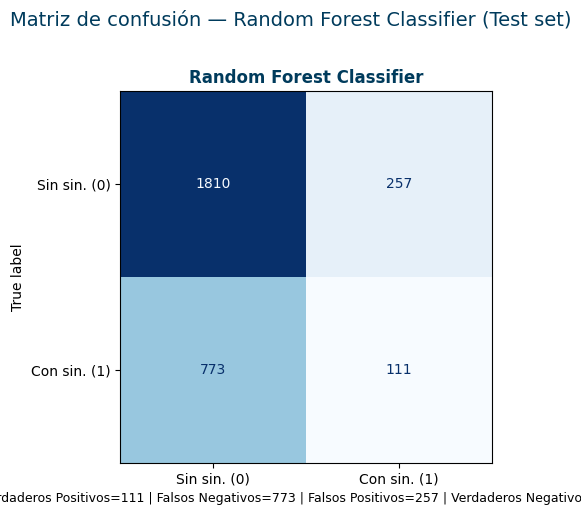

In [56]:
model_name = "Random Forest Classifier"
y_pred = y_pred_rf_class
y_true = y_test

fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sin sin. (0)", "Con sin. (1)"],
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(model_name, fontsize=12, color=NAVY, fontweight="bold")
tn, fp, fn, tp = cm.ravel()
ax.set_xlabel(f"Verdaderos Positivos={tp} | Falsos Negativos={fn} | Falsos Positivos={fp} | Verdaderos Negativos={tn}", fontsize=9)

plt.suptitle("Matriz de confusión — Random Forest Classifier (Test set)", fontsize=14, color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

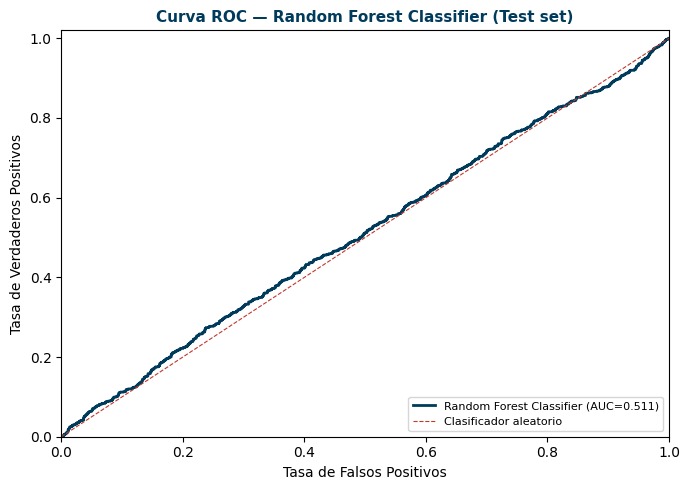

In [57]:
fig, ax = plt.subplots(figsize=(7, 5))

# Curva ROC para Random Forest Classifier
fpr, tpr, _ = roc_curve(y_test, y_pred_rf_proba)
auc = roc_auc_score(y_test, y_pred_rf_proba)
ax.plot(fpr, tpr, color=NAVY, linewidth=2.0,
         label=f"Random Forest Classifier (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "--", color=RED, linewidth=0.8, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curva ROC — Random Forest Classifier (Test set)", fontsize=11, color=NAVY, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

## XGBoost (Variable Binaria)

In [58]:
# Estas variables las definimos en el equipo como las relevantes a utilizar en el modelo.

# Variables predictoras
FEATURE_COLUMNS = ['edad', 'plan', 'sexo', 'canal_venta', 'marca_vehiculo',
                   'tipo_vehiculo', 'modelo_vehiculo', 'estado']

# Definir columnas numéricas y categóricas dentro de FEATURE_COLUMNS
NUMERIC_FEATURES = ["edad"]
CAT_FEATURES = ['plan', 'sexo', 'canal_venta', 'marca_vehiculo',
                   'tipo_vehiculo', 'modelo_vehiculo', 'estado']

TARGET = "ocurrencia_siniestro" # Already defined earlier, but redefine for clarity in this section

X_raw = df_autos[FEATURE_COLUMNS]
y     = df_autos[TARGET]

# Verificaciones de leakage
for t in TARGET_COLUMNS: # TARGET_COLUMNS is ['prima_neta','n_siniestros','monto_pagado']
    assert t not in X_raw.columns, f"Leakage: {t} en X_raw"
assert "id_poliza_sin" not in X_raw.columns # This was a check from a previous example, not strictly necessary but good for consistency
print("✓ Sin leakage de targets ni id_poliza_sin")
print(f"  Features numéricas : {len(NUMERIC_FEATURES)}")
print(f"  Features categóricas: {len(CAT_FEATURES)}")
print(f"  Total              : {len(FEATURE_COLUMNS)}")

# ── Split principal 80/20 estratificado ────────────────────────────────────
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"\nTrain completo: {X_train_all.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Proporción clase 1 — train: {y_train_all.mean():.4f}  |  test: {y_test.mean():.4f}")

# ── Submuestra estratificada para entrenamiento (siguiendo el patrón de RF y SVM) ──────────────
N_SUB = 10_000 # Same size as used for SVM and RF training subsample
X_train, _, y_train, _ = train_test_split(
    X_train_all, y_train_all,
    train_size=N_SUB,
    random_state=SEED,
    stratify=y_train_all,
)
print(f"\nSubmuestra de entrenamiento: {X_train.shape[0]:,} obs. (estratificada de train_all)")
print(f"Proporción clase 1 en submuestra: {y_train.mean():.4f}")

✓ Sin leakage de targets ni id_poliza_sin
  Features numéricas : 1
  Features categóricas: 7
  Total              : 8

Train completo: 11,801  |  Test: 2,951
Proporción clase 1 — train: 0.2996  |  test: 0.2996

Submuestra de entrenamiento: 10,000 obs. (estratificada de train_all)
Proporción clase 1 en submuestra: 0.2996


In [59]:
# Preprocesador para XGBoost (y otros modelos de árboles)
#
# Las variables numéricas NO se escalan ("passthrough") porque los árboles basan
# sus divisiones en el orden de los valores, haciéndolos invariables a transformaciones
# monótonas como la estandarización.
# Para OHE, mantenemos drop=None. Aunque los árboles no calculan distancias,
# retener todas las columnas permite que el algoritmo aísle cualquier categoría
# en un solo split (si hiciéramos drop="first", aislar la categoría de referencia
# le tomaría al árbol N-1 splits).
def make_xgb_preprocessor() -> ColumnTransformer:
    """Crea una instancia nueva del preprocesador para modelos basados en árboles."""
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", NUMERIC_FEATURES),
            ("cat", OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False),
             CAT_FEATURES),
        ],
        remainder="drop",
    )

# Dimensión del espacio transformado — instancia de verificación
_pre_check_xgb = make_xgb_preprocessor().fit(X_train)
X_tr_xgb_transformed = _pre_check_xgb.transform(X_train)

print(f"Dimensión del espacio transformado (XGB): {X_tr_xgb_transformed.shape[1]} features")
print(f"  Numéricas (sin escalar):      {len(NUMERIC_FEATURES)}")
print(f"  Categóricas (OHE completo):   {X_tr_xgb_transformed.shape[1] - len(NUMERIC_FEATURES)}")

Dimensión del espacio transformado (XGB): 56 features
  Numéricas (sin escalar):      1
  Categóricas (OHE completo):   55


In [60]:
from xgboost import XGBClassifier

# XGBoost Classifier
pipeline_xgb = Pipeline([
    ("preprocessor", make_xgb_preprocessor()),
    ("xgb", XGBClassifier(
        objective='binary:logistic', # For binary classification
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False, # Suppress warning
        eval_metric='logloss', # Evaluation metric
        random_state=SEED,
        n_jobs=-1,
        scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1]) # Handle class imbalance
    )),
])

print("Entrenando XGBoost Classifier (n_estimators=150, max_depth=5, learning_rate=0.1)...")
t0 = time.time()
pipeline_xgb.fit(X_train, y_train)
t_xgb = time.time() - t0
print(f"  Tiempo de entrenamiento: {t_xgb:.1f} s")

# Predicciones
y_pred_xgb_proba = pipeline_xgb.predict_proba(X_test)[:, 1] # Probabilities for ROC-AUC and AP
y_pred_xgb_class = pipeline_xgb.predict(X_test) # Class predictions for Balanced Accuracy and F1

# Cálculo de métricas
auc_xgb = roc_auc_score(y_test, y_pred_xgb_proba)
ap_xgb = average_precision_score(y_test, y_pred_xgb_proba)
ba_xgb = balanced_accuracy_score(y_test, y_pred_xgb_class)
f1_xgb = f1_score(y_test, y_pred_xgb_class)

# Impresión de resultados
print(f"\nXGBoost Classifier (n=150, max_depth=5, learning_rate=0.1):")
print(f"  ROC-AUC:           {auc_xgb:.4f}")
print(f"  Average Precision: {ap_xgb:.4f}")
print(f"  Balanced Accuracy: {ba_xgb:.4f}")
print(f"  F1-Score:          {f1_xgb:.4f}")

Entrenando XGBoost Classifier (n_estimators=150, max_depth=5, learning_rate=0.1)...
  Tiempo de entrenamiento: 0.3 s

XGBoost Classifier (n=150, max_depth=5, learning_rate=0.1):
  ROC-AUC:           0.5072
  Average Precision: 0.3082
  Balanced Accuracy: 0.5064
  F1-Score:          0.3430


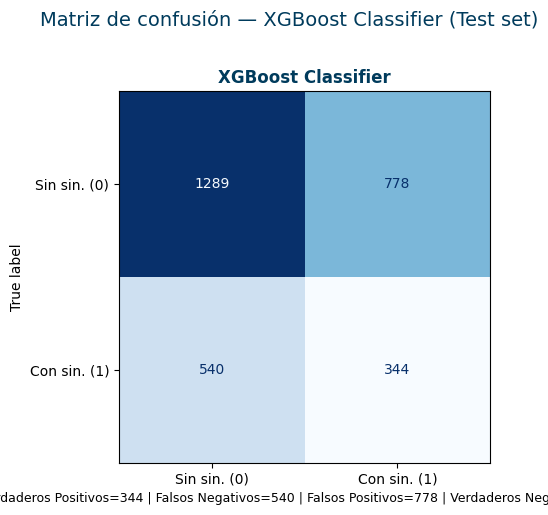

In [61]:
model_name = "XGBoost Classifier"
y_pred = y_pred_xgb_class
y_true = y_test

fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sin sin. (0)", "Con sin. (1)"],
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(model_name, fontsize=12, color=NAVY, fontweight="bold")
tn, fp, fn, tp = cm.ravel()
ax.set_xlabel(f"Verdaderos Positivos={tp} | Falsos Negativos={fn} | Falsos Positivos={fp} | Verdaderos Negativos={tn}", fontsize=9)

plt.suptitle("Matriz de confusión — XGBoost Classifier (Test set)", fontsize=14, color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

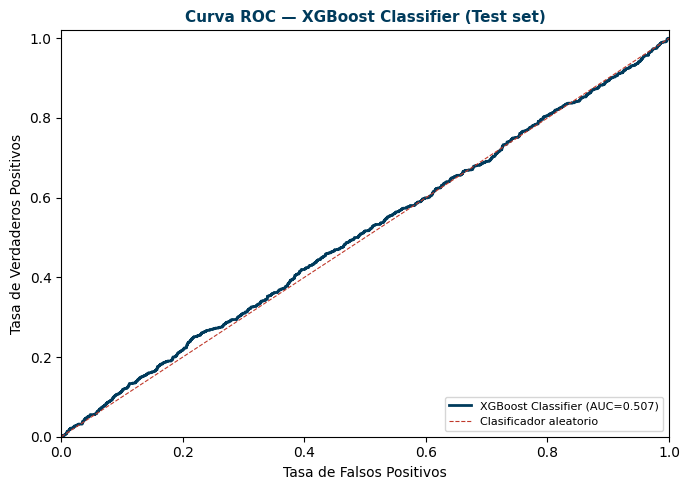

In [62]:
fig, ax = plt.subplots(figsize=(7, 5))

# Curva ROC para XGBoost Classifier
fpr, tpr, _ = roc_curve(y_test, y_pred_xgb_proba)
auc = roc_auc_score(y_test, y_pred_xgb_proba)
ax.plot(fpr, tpr, color=NAVY, linewidth=2.0,
         label=f"XGBoost Classifier (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "--", color=RED, linewidth=0.8, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curva ROC — XGBoost Classifier (Test set)", fontsize=11, color=NAVY, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

# Variables para aprendizaje no supervisado

In [63]:
# --- 1. CONFIGURACIÓN Y DEFINICIONES ---
# (Tus listas originales integradas)
cols_features = [
    'edad', 'sexo', 'estado_civil', 'ocupacion', 'plan',
    'fecha_emision', 'fecha_inicio_vigencia', 'fecha_fin_vigencia',
    'num_renovaciones', 'status_poliza', 'motivo_baja', 'canal_venta',
    'marca_vehiculo', 'modelo_vehiculo', 'tipo_vehiculo', 'suma_asegurada',
    'deducible', 'prima_total', 'forma_pago', 'estado', 'codigo_postal',
    'region', 'monto_reclamado', 'tiene_abierto', 'prima_mensual',
    'nivel_riesgo', 'anio_emision', 'mes_emision', 'trimestre',
    'segmento_prima_fijo', 'cuartil_prima', 'anio_poliza',
    'antiguedad_vehiculo', 'g_edad'
]
cols_target = ['prima_neta','n_siniestros','monto_pagado']
num_features = ['edad', 'num_renovaciones', 'suma_asegurada','antiguedad_vehiculo']

cat_features = ['plan','canal_venta', 'tipo_vehiculo', 'estado', 'nivel_riesgo']



DBSCAN

In [64]:
# Lectura de la base de datos original.
df_original= pd.read_parquet('cartera_q1_2026_final.parquet')
conteo_ramos = df_original['ramo'].value_counts()

print(df_original.shape)
display(df_original[:3])

(50000, 52)


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,ramo,plan,fecha_emision,fecha_inicio_vigencia,fecha_fin_vigencia,num_renovaciones,status_poliza,motivo_baja,canal_venta,marca_vehiculo,modelo_vehiculo,tipo_vehiculo,suma_asegurada,deducible,prima_neta,prima_total,forma_pago,agente_id,estado,municipio,codigo_postal,nombre_agente,region,tipo_agente,comision_pct,n_siniestros,monto_reclamado,monto_pagado,tiene_abierto,tipo_principal,prima_mensual,loss_ratio,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,Vida,10 anios,2021-11-23,2021-11-23,2022-11-23,4,Vigente,NaN,Banca Seguros,NaN,NaN,NaN,3000000,NaN,54000.0,67651.20,Mensual,AG054,Veracruz,Poza Rica,36619.0,Enrique Castillo,Chihuahua,Independiente,0.0871,0.0,0.0,0.0,False,None,5637.600,0.0,5892.41952,BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,Autos,Amplia Plus,2019-08-19,2019-08-19,2020-08-19,0,Vigente,NaN,Agente,Hyundai,2024.0,Compacto,150000,8000.0,5250.0,6394.50,Trimestral,AG004,Michoacan,Morelia,58889.0,Patricia Rios,Veracruz,Independiente,0.1380,0.0,0.0,0.0,False,None,532.875,0.0,882.44100,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,GMM,Basico,2022-07-11,2022-07-11,2023-07-11,0,Vigente,NaN,Banca Seguros,NaN,NaN,NaN,800000,5000.0,17600.0,22049.28,Mensual,AG051,Baja California,Tecate,45784.0,Manuel Mendoza,Chihuahua,Independiente,0.0905,0.0,0.0,0.0,False,None,1837.440,0.0,1995.45984,BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM


In [65]:
# Selección de los registros cuyo ramo es Autos
df_autos = df_original[df_original['ramo'] == 'Autos'].copy()

df_autos['antiguedad_vehiculo'] = df_autos['anio_poliza'] - df_autos['modelo_vehiculo']

print(df_autos.shape)
display(df_autos[:3])

(14752, 53)


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,ramo,plan,fecha_emision,fecha_inicio_vigencia,fecha_fin_vigencia,num_renovaciones,status_poliza,motivo_baja,canal_venta,marca_vehiculo,modelo_vehiculo,tipo_vehiculo,suma_asegurada,deducible,prima_neta,prima_total,forma_pago,agente_id,estado,municipio,codigo_postal,nombre_agente,region,tipo_agente,comision_pct,n_siniestros,monto_reclamado,monto_pagado,tiene_abierto,tipo_principal,prima_mensual,loss_ratio,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo,antiguedad_vehiculo
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,Autos,Amplia Plus,2019-08-19,2019-08-19,2020-08-19,0,Vigente,NaN,Agente,Hyundai,2024.0,Compacto,150000,8000.0,5250.0,6394.5,Trimestral,AG004,Michoacan,Morelia,58889.0,Patricia Rios,Veracruz,Independiente,0.1380,0.0,0.0,0.0,False,None,532.875000,0.0,882.44100,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos,-5.0
5,POL-000006,Aut-20-000006,Pedro,Castillo,Morales,CAPM010426MH6,25,M,Viudo,Jubilado,Autos,RC+LT,2020-03-18,2020-03-18,2021-03-18,1,Vigente,NaN,Agente,Toyota,2024.0,Compacto,200000,8000.0,7000.0,8120.0,Anual,AG052,Guanajuato,Irapuato,55060.0,Jose Navarro,Jalisco,Promotor,0.1253,0.0,0.0,0.0,False,None,676.666667,0.0,1017.43600,BAJO,2020,3,1,Alta,Q1,AUT,2020,Autos,-4.0
9,POL-000010,Aut-21-000010,Laura,Silva,Diaz,SILD630414LI6,63,M,Divorciado,Contador,Autos,Amplia Plus,2021-12-27,2021-12-27,2022-12-27,0,Vigente,NaN,Broker,Hyundai,2016.0,Deportivo,200000,5000.0,7000.0,8363.6,Semestral,AG062,Michoacan,Apatzingan,NaN,Martha Medina,Queretaro,Empresa,0.0881,0.0,0.0,0.0,False,None,696.966667,0.0,736.83316,BAJO,2021,12,4,Alta,Q2,AUT,2021,Autos,5.0


In [66]:
df_autos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14752 entries, 1 to 49997
Data columns (total 53 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_poliza              14752 non-null  object        
 1   num_poliza             14752 non-null  object        
 2   nombre                 14752 non-null  category      
 3   apellido_paterno       14752 non-null  category      
 4   apellido_materno       14752 non-null  category      
 5   rfc                    14752 non-null  object        
 6   edad                   14752 non-null  int8          
 7   sexo                   14752 non-null  category      
 8   estado_civil           14752 non-null  category      
 9   ocupacion              13568 non-null  category      
 10  ramo                   14752 non-null  category      
 11  plan                   14752 non-null  category      
 12  fecha_emision          14752 non-null  datetime64[ns]
 13  fecha_

In [67]:
#Aplicamos la metodología DBSCAN a los datos seleccionados


#plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
#warnings.filterwarnings("ignore", category=FutureWarning)
#warnings.filterwarnings("ignore", category=UserWarning)

#df = df_autos(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df_autos.shape[0]:,} filas x {df_autos.shape[1]} columnas")

CLUSTERING_FEATURES=num_features
TARGET_COLUMNS= cols_target
FEATURE_COLUMNS=cols_features

# ── Regla de seguridad: el clustering NUNCA usa targets ni identificadores ────
assert set(CLUSTERING_FEATURES).isdisjoint(set(TARGET_COLUMNS)), \
    "CLUSTERING_FEATURES no debe intersecar TARGET_COLUMNS"
assert "id_poliza_sin" not in CLUSTERING_FEATURES, "id_poliza_sin no es feature de clustering"
assert set(CLUSTERING_FEATURES).issubset(set(FEATURE_COLUMNS)), \
    "CLUSTERING_FEATURES debe ser subconjunto de FEATURE_COLUMNS"
print("Variables de clustering (canonicas):", CLUSTERING_FEATURES)
print("Excluidas del ajuste: id_poliza_sin y todos los targets:", TARGET_COLUMNS)
print("Verificacion CLUSTERING_FEATURES ∩ TARGET_COLUMNS = vacio: OK")

Dataset cargado: 14,752 filas x 53 columnas
Variables de clustering (canonicas): ['edad', 'num_renovaciones', 'suma_asegurada', 'antiguedad_vehiculo']
Excluidas del ajuste: id_poliza_sin y todos los targets: ['prima_neta', 'n_siniestros', 'monto_pagado']
Verificacion CLUSTERING_FEATURES ∩ TARGET_COLUMNS = vacio: OK


In [68]:
# Preparación: submuestra, escalamiento y PCA (decisión de modelación)
SEED  = 20260618
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
DBSCAN_SUB = len(df_autos)              #int(len(df_autos)/3)
MIN_SAMPLES = 5


sub_db = df_autos.sample(n=DBSCAN_SUB, random_state=SEED)
X_db_scaled = StandardScaler().fit_transform(sub_db[CLUSTERING_FEATURES].to_numpy(dtype=float))
pca_db = PCA(n_components=2, random_state=SEED).fit(X_db_scaled)
X_db = pca_db.transform(X_db_scaled)
db_var = pca_db.explained_variance_ratio_
print(f"Submuestra DBSCAN: {X_db.shape[0]:,} obs. (determinista, random_state=SEED)")
print(f"PC1+PC2 explican {(db_var[0]+db_var[1])*100:.0f}% de la varianza en la submuestra")


Submuestra DBSCAN: 14,752 obs. (determinista, random_state=SEED)
PC1+PC2 explican 50% de la varianza en la submuestra


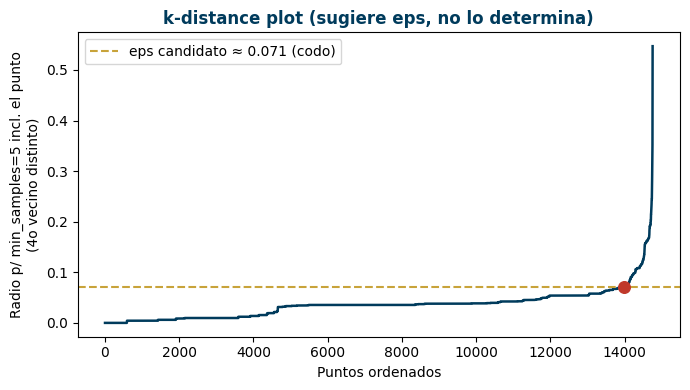

eps candidato en el codo: 0.071  |  min_samples=5
kneighbors incluye el propio punto (dist 0); la ultima columna es el 4o vecino distinto.


In [69]:
# Elección de eps con el k-distance plot

def knee_index(y: np.ndarray) -> int:
    """Indice del punto de maxima distancia a la cuerda (determinista).

    Sobre una curva monotona ordenada, devuelve el indice del punto mas alejado de la
    recta que une el primer y el ultimo punto. Es una HEURISTICA del codo: solo sugiere
    un valor candidato, no una curvatura exacta ni una frontera cierta.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    x = np.arange(n, dtype=float)
    x1, x2, y1, y2 = x[0], x[-1], y[0], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.hypot(y2 - y1, x2 - x1)
    d = num / (den if den > 0 else 1.0)
    return int(np.argmax(d))

from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_db)
dist_nn, _ = nn.kneighbors(X_db)      # col 0 = el propio punto (distancia 0)
kth = np.sort(dist_nn[:, -1])         # ultima col = radio p/ min_samples incl. p (4o vecino distinto)
eps_idx = knee_index(kth)
eps_db = float(round(kth[eps_idx], 3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(len(kth)), kth, color=NAVY, lw=1.8)
ax.axhline(eps_db, color=GOLD, ls="--", label=f"eps candidato ≈ {eps_db} (codo)")
ax.scatter([eps_idx], [kth[eps_idx]], s=70, color=RED, zorder=5)
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel(f"Radio p/ min_samples={MIN_SAMPLES} incl. el punto\n(4o vecino distinto)")
ax.set_title("k-distance plot (sugiere eps, no lo determina)", color=NAVY, fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()
print(f"eps candidato en el codo: {eps_db}  |  min_samples={MIN_SAMPLES}")
print("kneighbors incluye el propio punto (dist 0); la ultima columna es el 4o vecino distinto.")


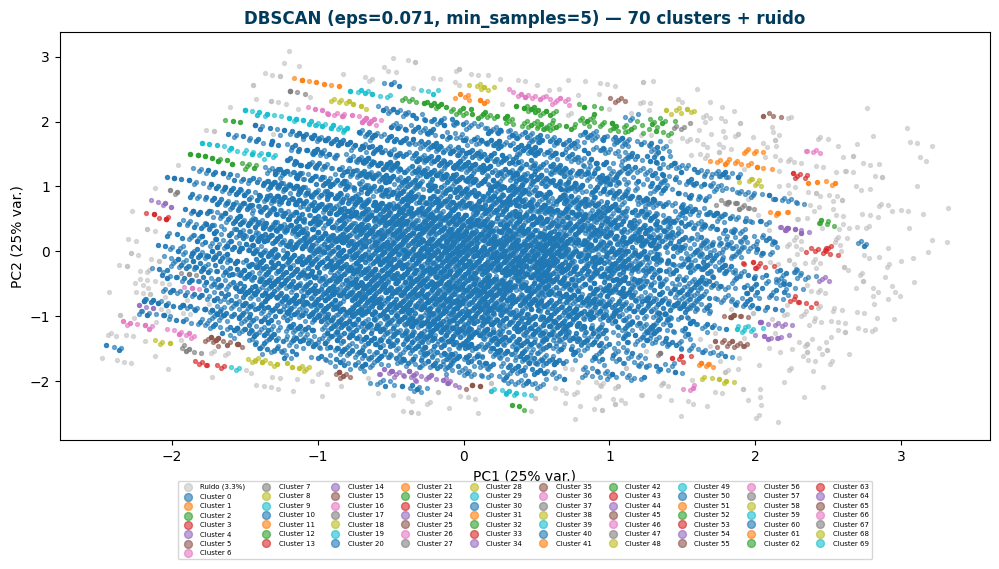

DBSCAN clusters=70  ruido=3.3%  silhouette(sin ruido)=-0.2937
Cluster dominante concentra 93.4% de los puntos no-ruido.
Interpretacion honesta: un cluster dominante + fragmentos pequenos y silhouette bajo indican
separacion DEBIL en esta configuracion (eps/min_samples/PCA). No es una segmentacion concluyente.


In [70]:
## 5. Ajuste de DBSCAN y resultados


from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

db = DBSCAN(eps=eps_db, min_samples=MIN_SAMPLES).fit(X_db)
db_labels = db.labels_
db_n_clusters = int(len(set(db_labels)) - (1 if -1 in db_labels else 0))
db_noise = float(np.mean(db_labels == -1))

mask = db_labels != -1
if db_n_clusters >= 2 and mask.sum() > db_n_clusters:
    db_sil = float(silhouette_score(X_db[mask], db_labels[mask],
                                    sample_size=min(5000, int(mask.sum())), random_state=SEED))
else:
    db_sil = float("nan")

# Tamanos de cluster (para interpretacion honesta)
db_cluster_sizes = pd.Series(db_labels[mask]).value_counts().sort_values(ascending=False)
dom_frac = float(db_cluster_sizes.iloc[0] / mask.sum()) if mask.sum() else float("nan")

# Colores distintos para todos los clusters (evita leyenda enganosa con colores repetidos)
cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(12, 6))
noise = db_labels == -1
ax.scatter(X_db[noise, 0], X_db[noise, 1], s=8, color="#BBBBBB", alpha=0.5, label=f"Ruido ({db_noise*100:.1f}%)")
for ci, c in enumerate(sorted(set(db_labels) - {-1})):
    m = db_labels == c
    ax.scatter(X_db[m, 0], X_db[m, 1], s=8, alpha=0.6, color=cmap(ci % 10), label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({db_var[0]*100:.0f}% var.)"); ax.set_ylabel(f"PC2 ({db_var[1]*100:.0f}% var.)")
ax.set_title(f"DBSCAN (eps={eps_db}, min_samples={MIN_SAMPLES}) — {db_n_clusters} clusters + ruido",
             color=NAVY, fontweight="bold")
ax.legend(markerscale=2, fontsize=5, ncol=10, loc="lower center", bbox_to_anchor=(0.5, -0.3));
#plt.tight_layout();
plt.subplots_adjust(bottom=0.2)
plt.show()

print(f"DBSCAN clusters={db_n_clusters}  ruido={db_noise*100:.1f}%  silhouette(sin ruido)={db_sil:.4f}")
print(f"Cluster dominante concentra {dom_frac*100:.1f}% de los puntos no-ruido.")
print("Interpretacion honesta: un cluster dominante + fragmentos pequenos y silhouette bajo indican")
print("separacion DEBIL en esta configuracion (eps/min_samples/PCA). No es una segmentacion concluyente.")


In [71]:
# 1. Asignamos los resultados de DBSCAN
df_autos['cluster'] = db_labels

# 2. Agrupamos y calculamos las medias
perfil_clusters = df_autos[df_autos['cluster'] != -1].groupby('cluster')[CLUSTERING_FEATURES].mean()

# 3. Agregamos el conteo
perfil_clusters['conteo'] = df_autos[df_autos['cluster'] != -1].groupby('cluster').size().astype(int)

# 4. NO transponemos (para que los clusters se mantengan como filas/formato vertical)
# perfil_display = perfil_clusters

# 5. Aplicamos formato con Styler
import pandas as pd

# Aplicamos el formato directamente a las columnas:
# - Las variables (features) con 2 decimales
# - La columna 'conteo' como entero
style = perfil_clusters.style.format(
    subset=CLUSTERING_FEATURES,
    formatter="{:,.2f}"
).format(
    subset='conteo',
    formatter="{:,.0f}"
)

print("Perfil de los clusters (formato vertical):")
display(style)

Perfil de los clusters (formato vertical):


,edad,num_renovaciones,suma_asegurada,antiguedad_vehiculo,conteo
cluster,,,,,
0,43.24,1.23,"409,394.01",1.50,"13,317"
1,43.08,1.08,"330,769.23",0.00,13
2,40.87,1.30,"395,000.00",0.93,30
3,41.20,0.90,"305,000.00",3.10,10
4,41.87,1.23,"424,358.97",1.69,39
5,43.90,1.80,"440,000.00",3.50,10
6,41.86,1.17,"437,142.86",0.63,35
7,42.12,0.75,"581,250.00",3.50,8
8,35.11,1.11,"550,000.00",3.22,9


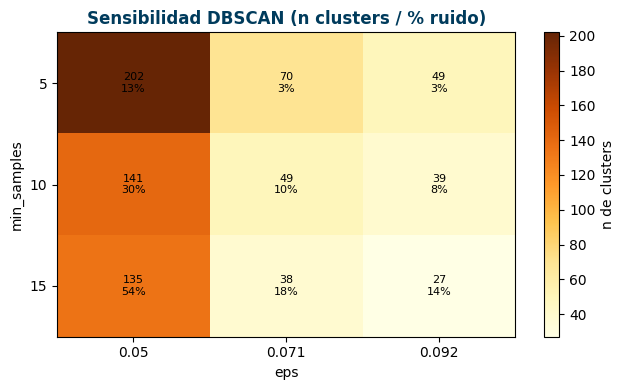

Al aumentar eps, el % de ruido NO aumenta (tiende a disminuir).
El numero de clusters NO es necesariamente monotono en eps: pueden aparecer grupos desde el
ruido y luego fusionarse. Ej.: en alguna fila el conteo pasa de 3 a 4 clusters al subir eps.


In [72]:
## 6. Análisis de sensibilidad a eps y min_samples
eps_grid = [round(eps_db * f, 3) for f in (0.7, 1.0, 1.3)]
ms_grid = [5, 10, 15]
sens_nclus = np.zeros((len(ms_grid), len(eps_grid)), dtype=int)
sens_noise = np.zeros((len(ms_grid), len(eps_grid)), dtype=float)
for i, ms in enumerate(ms_grid):
    for j, ep in enumerate(eps_grid):
        lab = DBSCAN(eps=ep, min_samples=ms).fit_predict(X_db)
        sens_nclus[i, j] = len(set(lab)) - (1 if -1 in lab else 0)
        sens_noise[i, j] = float(np.mean(lab == -1))

fig, ax = plt.subplots(figsize=(6.5, 4))
im = ax.imshow(sens_nclus, cmap="YlOrBr", aspect="auto")
ax.set_xticks(range(len(eps_grid))); ax.set_xticklabels(eps_grid)
ax.set_yticks(range(len(ms_grid))); ax.set_yticklabels(ms_grid)
ax.set_xlabel("eps"); ax.set_ylabel("min_samples")
for i in range(len(ms_grid)):
    for j in range(len(eps_grid)):
        ax.text(j, i, f"{sens_nclus[i,j]}\n{sens_noise[i,j]*100:.0f}%", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="n de clusters")
ax.set_title("Sensibilidad DBSCAN (n clusters / % ruido)", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()
print("Al aumentar eps, el % de ruido NO aumenta (tiende a disminuir).")
print("El numero de clusters NO es necesariamente monotono en eps: pueden aparecer grupos desde el")
print("ruido y luego fusionarse. Ej.: en alguna fila el conteo pasa de 3 a 4 clusters al subir eps.")


In [73]:
## 7. Interpretación de observaciones atípicas (análisis posterior)

post = sub_db[TARGET_COLUMNS].copy()
post["es_ruido"] = (db_labels == -1)
resumen = post.groupby("es_ruido").agg(
    prima_neta_media=("prima_neta", "mean"),
    tasa_siniestro=("n_siniestros", "mean"),
    siniestro_medio=("monto_pagado", "mean"),
    n=("prima_neta", "size"),
).round(3)
print("ANALISIS POSTERIOR — ruido vs no-ruido (los targets NO formaron los clusters):")
print(resumen.to_string())
print()
print("Los atipicos son candidatos a revision, no una etiqueta de fraude ni de riesgo por si solos.")


ANALISIS POSTERIOR — ruido vs no-ruido (los targets NO formaron los clusters):
          prima_neta_media  tasa_siniestro  siniestro_medio      n
es_ruido                                                          
False            14298.661           0.358         4364.566  14262
True             15603.571           0.367         4596.047    490

Los atipicos son candidatos a revision, no una etiqueta de fraude ni de riesgo por si solos.


INCREMENTO DE EPS. Utilizamos un epsilon mayor para reducir el número de clústers

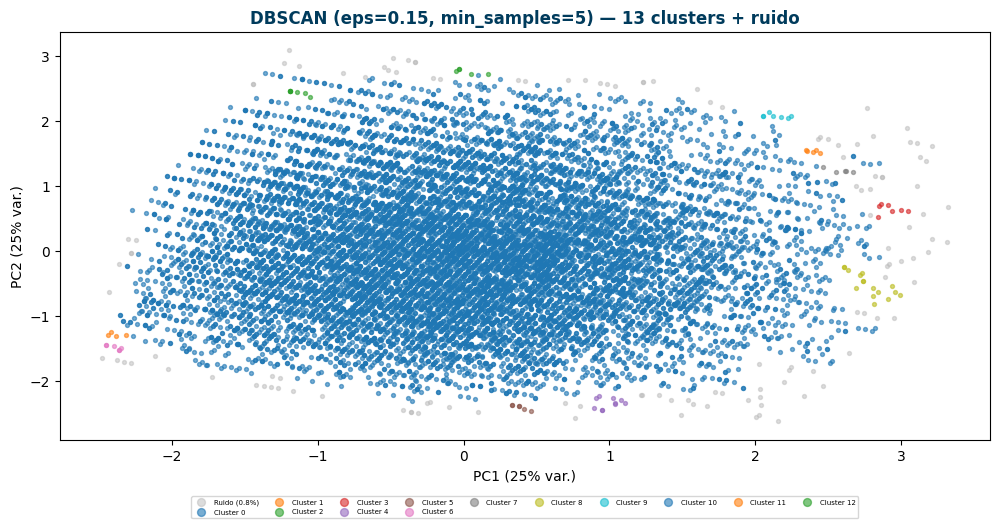

DBSCAN clusters=13  ruido=0.8%  silhouette(sin ruido)=-0.0754
Cluster dominante concentra 99.4% de los puntos no-ruido.
Interpretacion honesta: un cluster dominante + fragmentos pequenos y silhouette bajo indican
separacion DEBIL en esta configuracion (eps/min_samples/PCA). No es una segmentacion concluyente.


In [74]:
## 5.a Ajuste de DBSCAN, EPS=0.15  y resultados


from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

db = DBSCAN(eps=0.15, min_samples=MIN_SAMPLES).fit(X_db)
db_labels = db.labels_
db_n_clusters = int(len(set(db_labels)) - (1 if -1 in db_labels else 0))
db_noise = float(np.mean(db_labels == -1))

mask = db_labels != -1
if db_n_clusters >= 2 and mask.sum() > db_n_clusters:
    db_sil = float(silhouette_score(X_db[mask], db_labels[mask],
                                    sample_size=min(5000, int(mask.sum())), random_state=SEED))
else:
    db_sil = float("nan")

# Tamanos de cluster (para interpretacion honesta)
db_cluster_sizes = pd.Series(db_labels[mask]).value_counts().sort_values(ascending=False)
dom_frac = float(db_cluster_sizes.iloc[0] / mask.sum()) if mask.sum() else float("nan")

# Colores distintos para todos los clusters (evita leyenda enganosa con colores repetidos)
cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(12, 6))
noise = db_labels == -1
ax.scatter(X_db[noise, 0], X_db[noise, 1], s=8, color="#BBBBBB", alpha=0.5, label=f"Ruido ({db_noise*100:.1f}%)")
for ci, c in enumerate(sorted(set(db_labels) - {-1})):
    m = db_labels == c
    ax.scatter(X_db[m, 0], X_db[m, 1], s=8, alpha=0.6, color=cmap(ci % 10), label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({db_var[0]*100:.0f}% var.)"); ax.set_ylabel(f"PC2 ({db_var[1]*100:.0f}% var.)")
ax.set_title(f"DBSCAN (eps=0.15, min_samples={MIN_SAMPLES}) — {db_n_clusters} clusters + ruido",
             color=NAVY, fontweight="bold")
ax.legend(markerscale=2, fontsize=5, ncol=10, loc="lower center", bbox_to_anchor=(0.5, -0.2));
#plt.tight_layout();
plt.subplots_adjust(bottom=0.2)
plt.show()

print(f"DBSCAN clusters={db_n_clusters}  ruido={db_noise*100:.1f}%  silhouette(sin ruido)={db_sil:.4f}")
print(f"Cluster dominante concentra {dom_frac*100:.1f}% de los puntos no-ruido.")
print("Interpretacion honesta: un cluster dominante + fragmentos pequenos y silhouette bajo indican")
print("separacion DEBIL en esta configuracion (eps/min_samples/PCA). No es una segmentacion concluyente.")


In [75]:
# 1. Asignamos los resultados de DBSCAN
df_autos['cluster'] = db_labels

# 2. Agrupamos y calculamos (aseguramos que conteo sea entero)
perfil_clusters = df_autos[df_autos['cluster'] != -1].groupby('cluster')[CLUSTERING_FEATURES].mean()
perfil_clusters['conteo'] = df_autos[df_autos['cluster'] != -1].groupby('cluster').size().astype(int)

# 3. Transponemos para que las variables sean filas
perfil_display = perfil_clusters.T

# 4. Aplicamos formato con Styler
# IndexSlice selecciona las filas por nombre para aplicar formatos distintos
import pandas as pd # Asegúrate de tener pandas importado

style = perfil_display.style.format(subset=pd.IndexSlice[CLUSTERING_FEATURES, :], formatter="{:,.2f}") \
                            .format(subset=pd.IndexSlice['conteo', :], formatter="{:,.0f}")

print("Perfil de los 13 Clusters (medias):")
display(style)

Perfil de los 13 Clusters (medias):


cluster,0,1,2,3,4,5,6,7,8,9,10,11,12
edad,43.26,38.20,42.14,47.43,47.80,39.17,35.33,45.00,42.12,39.14,43.40,48.50,47.00
num_renovaciones,1.24,1.60,1.57,0.71,1.10,2.00,1.67,1.00,1.19,2.14,1.20,1.00,1.80
suma_asegurada,"409,976.62","490,000.00","414,285.71","442,857.14","415,000.00","250,000.00","350,000.00","330,000.00","396,875.00","521,428.57","300,000.00","537,500.00","290,000.00"
antiguedad_vehiculo,1.49,2.40,0.29,1.14,0.50,2.33,1.83,-0.20,2.31,-1.86,-2.20,4.25,2.00
conteo,"14,544",5,7,7,10,6,6,5,16,7,5,4,5


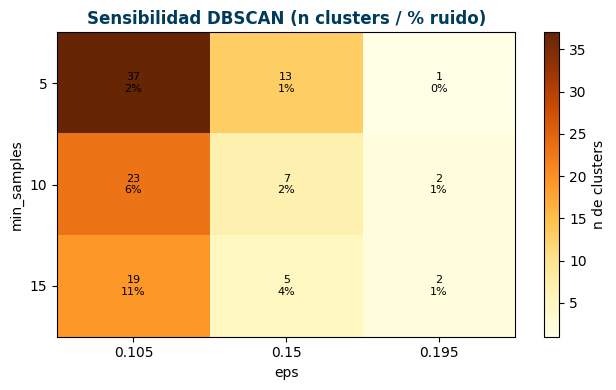

Al aumentar eps, el % de ruido NO aumenta (tiende a disminuir).
El numero de clusters NO es necesariamente monotono en eps: pueden aparecer grupos desde el
ruido y luego fusionarse. Ej.: en alguna fila el conteo pasa de 3 a 4 clusters al subir eps.


In [76]:
#eps_db=0.15

eps_grid = [round(0.15 * f, 3) for f in (0.7, 1.0, 1.3)]
ms_grid = [5, 10, 15]
sens_nclus = np.zeros((len(ms_grid), len(eps_grid)), dtype=int)
sens_noise = np.zeros((len(ms_grid), len(eps_grid)), dtype=float)
for i, ms in enumerate(ms_grid):
    for j, ep in enumerate(eps_grid):
        lab = DBSCAN(eps=ep, min_samples=ms).fit_predict(X_db)
        sens_nclus[i, j] = len(set(lab)) - (1 if -1 in lab else 0)
        sens_noise[i, j] = float(np.mean(lab == -1))

fig, ax = plt.subplots(figsize=(6.5, 4))
im = ax.imshow(sens_nclus, cmap="YlOrBr", aspect="auto")
ax.set_xticks(range(len(eps_grid))); ax.set_xticklabels(eps_grid)
ax.set_yticks(range(len(ms_grid))); ax.set_yticklabels(ms_grid)
ax.set_xlabel("eps"); ax.set_ylabel("min_samples")
for i in range(len(ms_grid)):
    for j in range(len(eps_grid)):
        ax.text(j, i, f"{sens_nclus[i,j]}\n{sens_noise[i,j]*100:.0f}%", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="n de clusters")
ax.set_title("Sensibilidad DBSCAN (n clusters / % ruido)", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()
print("Al aumentar eps, el % de ruido NO aumenta (tiende a disminuir).")
print("El numero de clusters NO es necesariamente monotono en eps: pueden aparecer grupos desde el")
print("ruido y luego fusionarse. Ej.: en alguna fila el conteo pasa de 3 a 4 clusters al subir eps.")


In [77]:
## 7. Interpretación de observaciones atípicas (análisis posterior)

post = sub_db[TARGET_COLUMNS].copy()
post["es_ruido"] = (db_labels == -1)
resumen = post.groupby("es_ruido").agg(
    prima_neta_media=("prima_neta", "mean"),
    tasa_siniestro=("n_siniestros", "mean"),
    siniestro_medio=("monto_pagado", "mean"),
    n=("prima_neta", "size"),
).round(3)
print("ANALISIS POSTERIOR — ruido vs no-ruido (los targets NO formaron los clusters):")
print(resumen.to_string())
print()
print("Los atipicos son candidatos a revision, no una etiqueta de fraude ni de riesgo por si solos.")


ANALISIS POSTERIOR — ruido vs no-ruido (los targets NO formaron los clusters):
          prima_neta_media  tasa_siniestro  siniestro_medio      n
es_ruido                                                          
False            14330.331           0.358         4395.002  14627
True             15708.000           0.376         1710.430    125

Los atipicos son candidatos a revision, no una etiqueta de fraude ni de riesgo por si solos.


### Aplicación de la metodología K-means

In [78]:
## Se crea la variable ruido
print(df_autos.shape)
df_autos["es_ruido"] = (db_labels == -1)
print(df_autos.shape)
df_autos[:3]

(14752, 54)
(14752, 55)


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,ramo,plan,fecha_emision,fecha_inicio_vigencia,fecha_fin_vigencia,num_renovaciones,status_poliza,motivo_baja,canal_venta,marca_vehiculo,modelo_vehiculo,tipo_vehiculo,suma_asegurada,deducible,prima_neta,prima_total,forma_pago,agente_id,estado,municipio,codigo_postal,nombre_agente,region,tipo_agente,comision_pct,n_siniestros,monto_reclamado,monto_pagado,tiene_abierto,tipo_principal,prima_mensual,loss_ratio,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo,antiguedad_vehiculo,cluster,es_ruido
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,Autos,Amplia Plus,2019-08-19,2019-08-19,2020-08-19,0,Vigente,NaN,Agente,Hyundai,2024.0,Compacto,150000,8000.0,5250.0,6394.5,Trimestral,AG004,Michoacan,Morelia,58889.0,Patricia Rios,Veracruz,Independiente,0.1380,0.0,0.0,0.0,False,None,532.875000,0.0,882.44100,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos,-5.0,0,False
5,POL-000006,Aut-20-000006,Pedro,Castillo,Morales,CAPM010426MH6,25,M,Viudo,Jubilado,Autos,RC+LT,2020-03-18,2020-03-18,2021-03-18,1,Vigente,NaN,Agente,Toyota,2024.0,Compacto,200000,8000.0,7000.0,8120.0,Anual,AG052,Guanajuato,Irapuato,55060.0,Jose Navarro,Jalisco,Promotor,0.1253,0.0,0.0,0.0,False,None,676.666667,0.0,1017.43600,BAJO,2020,3,1,Alta,Q1,AUT,2020,Autos,-4.0,0,False
9,POL-000010,Aut-21-000010,Laura,Silva,Diaz,SILD630414LI6,63,M,Divorciado,Contador,Autos,Amplia Plus,2021-12-27,2021-12-27,2022-12-27,0,Vigente,NaN,Broker,Hyundai,2016.0,Deportivo,200000,5000.0,7000.0,8363.6,Semestral,AG062,Michoacan,Apatzingan,NaN,Martha Medina,Queretaro,Empresa,0.0881,0.0,0.0,0.0,False,None,696.966667,0.0,736.83316,BAJO,2021,12,4,Alta,Q2,AUT,2021,Autos,5.0,0,False


In [79]:
print(f'Registros de Ruido: {df_autos[df_autos.es_ruido==1].shape}')
print(f'Registros Sin Ruido: {df_autos[df_autos.es_ruido==0].shape}')
print(f'Registros Totales: {df_autos.shape}')

Registros de Ruido: (125, 55)


Registros Sin Ruido: (14627, 55)
Registros Totales: (14752, 55)


#### K-Means sin ruido

In [80]:
from sklearn.preprocessing import StandardScaler

# Espacio de clustering canonico: 4 variables numericas escaladas
X = StandardScaler().fit_transform(df_autos[CLUSTERING_FEATURES].to_numpy(dtype=float))
print(f"Matriz de clustering X: {X.shape[0]:,} x {X.shape[1]} (features escaladas)")
print("Media por columna (≈0):", np.round(X.mean(axis=0), 3))
print("Desv. std por columna (≈1):", np.round(X.std(axis=0), 3))

Matriz de clustering X: 14,752 x 4 (features escaladas)
Media por columna (≈0): [-0. -0. -0. -0.]
Desv. std por columna (≈1): [1. 1. 1. 1.]


Espacio extendido (num + OHE): 39 dimensiones


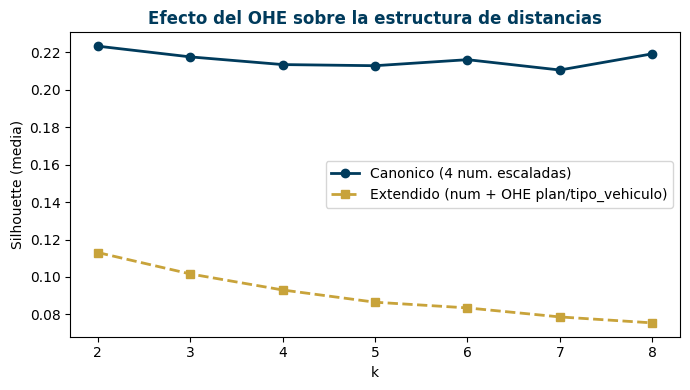

Decision de este material: espacio canonico numerico escalado como configuracion base.

CONCLUSIONES:
El que máximiza la media es 2, aunque en 8 cluster se tiene un incremento
Por lo tanto, consideraremos tomar 2 clusters


In [81]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = list(range(2, 9))
SILH_SAMPLE = 5_000

OHE_CATS = cat_features  # Variables que creemos afectaran más a los grupos.
assert set(OHE_CATS).issubset(set(FEATURE_COLUMNS))
assert set(OHE_CATS).isdisjoint(set(TARGET_COLUMNS))

ext_pre = ColumnTransformer([
    ("num", StandardScaler(), CLUSTERING_FEATURES),
    ("cat", OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False), OHE_CATS),
])
X_ext = ext_pre.fit_transform(df_autos[CLUSTERING_FEATURES + OHE_CATS])
print(f"Espacio extendido (num + OHE): {X_ext.shape[1]} dimensiones")

sil_canon, sil_ext = [], []
for k in K_RANGE:
    lc = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X)
    le = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X_ext)
    sil_canon.append(silhouette_score(X, lc, sample_size=SILH_SAMPLE, random_state=SEED))
    sil_ext.append(silhouette_score(X_ext, le, sample_size=SILH_SAMPLE, random_state=SEED))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_RANGE, sil_canon, "o-", color=NAVY, lw=2, label="Canonico (4 num. escaladas)")
ax.plot(K_RANGE, sil_ext, "s--", color=GOLD, lw=2, label="Extendido (num + OHE plan/tipo_vehiculo)")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette (media)")
ax.set_title("Efecto del OHE sobre la estructura de distancias", color=NAVY, fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()
print("Decision de este material: espacio canonico numerico escalado como configuracion base.")

print()
print('CONCLUSIONES:')
print('El que máximiza la media es 2, aunque en 8 cluster se tiene un incremento')
print('Por lo tanto, consideraremos tomar 2 clusters')

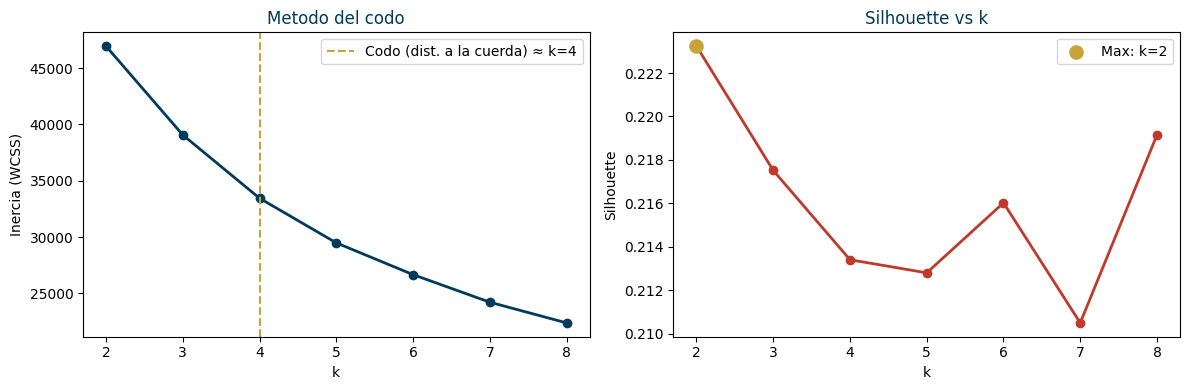

Codo (maxima distancia a la cuerda) sugiere k ≈ 4
Silhouette maximo en k=2 (silhouette=0.2232)
k seleccionada por codo + silhouette (la estabilidad se comprueba a continuacion).

CONCLUSIONES:
Si bien en el metodo del codo nos sugire tomar 4 cluster ya que es el que detecta con mayor inflexión,
el metodo de Silhouette coincide con la anterior vista de codo, en donde alcanza el punto máximo en 2 clusters
Por lo anterior, reforzamos nuestra propuesta de 2 grupos


In [82]:
def knee_index(y: np.ndarray) -> int:
    """Indice del punto de maxima distancia a la cuerda (determinista).

    Sobre una curva monotona ordenada, devuelve el indice del punto mas alejado de la
    recta que une el primer y el ultimo punto. Es una HEURISTICA del codo: solo sugiere
    un valor candidato, no una curvatura exacta ni una frontera cierta.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    x = np.arange(n, dtype=float)
    x1, x2, y1, y2 = x[0], x[-1], y[0], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.hypot(y2 - y1, x2 - x1)
    d = num / (den if den > 0 else 1.0)
    return int(np.argmax(d))


km_inertia, km_silhouette = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab = km.fit_predict(X)
    km_inertia.append(float(km.inertia_))
    km_silhouette.append(float(silhouette_score(X, lab, sample_size=SILH_SAMPLE, random_state=SEED)))

best_k = int(K_RANGE[int(np.argmax(km_silhouette))])
best_sil = float(max(km_silhouette))
elbow_k = int(K_RANGE[knee_index(np.array(km_inertia))])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_RANGE, km_inertia, "o-", color=NAVY, lw=2)
ax1.axvline(elbow_k, color=GOLD, ls="--", label=f"Codo (dist. a la cuerda) ≈ k={elbow_k}")
ax1.set_xlabel("k"); ax1.set_ylabel("Inercia (WCSS)"); ax1.set_title("Metodo del codo", color=NAVY); ax1.legend()
ax2.plot(K_RANGE, km_silhouette, "o-", color=RED, lw=2)
ax2.scatter([best_k], [best_sil], s=90, color=GOLD, zorder=5, label=f"Max: k={best_k}")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette"); ax2.set_title("Silhouette vs k", color=NAVY); ax2.legend()
plt.tight_layout(); plt.show()

print(f"Codo (maxima distancia a la cuerda) sugiere k ≈ {elbow_k}")
print(f"Silhouette maximo en k={best_k} (silhouette={best_sil:.4f})")
print("k seleccionada por codo + silhouette (la estabilidad se comprueba a continuacion).")

print()
print('CONCLUSIONES:')
print('Si bien en el metodo del codo nos sugire tomar 4 cluster ya que es el que detecta con mayor inflexión,')
print('el metodo de Silhouette coincide con la anterior vista de codo, en donde alcanza el punto máximo en 2 clusters')
print('Por lo anterior, reforzamos nuestra propuesta de 2 grupos')

In [83]:
from sklearn.metrics import adjusted_rand_score

# Estabilidad (comprobacion POSTERIOR): ARI entre ajustes con distinto random_state,
# cada uno con n_init=10, sobre las MISMAS 30,000 observaciones (ARI exige mismas obs.).
ref_lab = KMeans(n_clusters=best_k, n_init=10, random_state=SEED).fit_predict(X)
stab_aris = []
for s in (SEED + 1, SEED + 2, SEED + 3, SEED + 4, SEED + 5):
    lab_s = KMeans(n_clusters=best_k, n_init=10, random_state=s).fit_predict(X)
    stab_aris.append(float(adjusted_rand_score(ref_lab, lab_s)))
stab_ari_mean = float(np.mean(stab_aris))
print(f"Estabilidad — ARI medio entre {len(stab_aris)} ajustes con distinto random_state "
      f"(k={best_k}, n_init=10): {stab_ari_mean:.4f}")
print("(1.0 = particion identica entre ajustes; indica reproducibilidad de la solucion para el k ya")
print(" seleccionado bajo las semillas evaluadas; no selecciona k por si sola.)")
print(f"K-MEANS seleccion final: k={best_k}")

# Esto se hace para ver si la parte aleatoria nos llevo a esa selección de subclusters

Estabilidad — ARI medio entre 5 ajustes con distinto random_state (k=2, n_init=10): 0.8000
(1.0 = particion identica entre ajustes; indica reproducibilidad de la solucion para el k ya
 seleccionado bajo las semillas evaluadas; no selecciona k por si sola.)
K-MEANS seleccion final: k=2


In [84]:
CLUSTER_COLORS = ["#003B5C", "#C8A33A", "#2E7D44", "#C0392B", "#6A5ACD", "#008B8B", "#B8860B"]

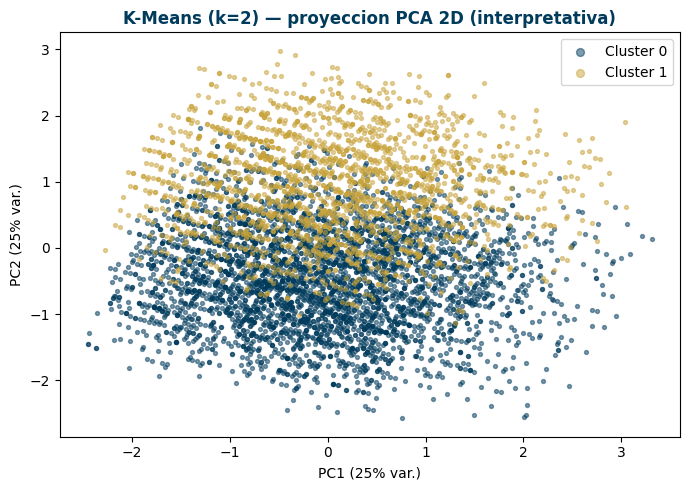

Inercia final (k=2): 46939.16
PC1+PC2 explican 50% de la varianza
Tamanos de cluster: [np.int64(9786), np.int64(4966)]


In [85]:
from sklearn.decomposition import PCA

km_final = KMeans(n_clusters=best_k, n_init=10, random_state=SEED)
km_labels = km_final.fit_predict(X)
km_inertia_final = float(km_final.inertia_)
km_sizes = pd.Series(km_labels).value_counts().sort_index()

pca = PCA(n_components=2, random_state=SEED).fit(X)
X_pca = pca.transform(X)
pca_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_pca), size=6000, replace=False)
for c in range(best_k):
    m = km_labels[idx] == c
    ax.scatter(X_pca[idx][m, 0], X_pca[idx][m, 1], s=8, alpha=0.5,
               color=CLUSTER_COLORS[c % len(CLUSTER_COLORS)], label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({pca_var[0]*100:.0f}% var.)"); ax.set_ylabel(f"PC2 ({pca_var[1]*100:.0f}% var.)")
ax.set_title(f"K-Means (k={best_k}) — proyeccion PCA 2D (interpretativa)", color=NAVY, fontweight="bold")
ax.legend(markerscale=2); plt.tight_layout(); plt.show()

print(f"Inercia final (k={best_k}): {km_inertia_final:.2f}")
print(f"PC1+PC2 explican {(pca_var[0]+pca_var[1])*100:.0f}% de la varianza")
print("Tamanos de cluster:", list(km_sizes.values))

In [86]:
prof = df_autos[CLUSTERING_FEATURES].copy()
prof["cluster"] = km_labels
profile_orig = prof.groupby("cluster").mean().round(1)
profile_orig["n"] = km_sizes.values
print("Perfil de cada cluster (unidades originales):")
print(profile_orig.to_string())

print()
print('CONCLUSIONES:')
print('- La variable que más discrimna es la Suma Asegurada')
print('- Con estos datos, podríamos cuestionarnos si considerar 2 clusters es lo más adecuado para segmentar la inforación,')
print('ya que fuera de la suma asegurada, el resto de los indicadores son muy similares.')

Perfil de cada cluster (unidades originales):
         edad  num_renovaciones  suma_asegurada  antiguedad_vehiculo     n
cluster                                                                   
0        43.2               1.2        262487.2                  1.5  9786
1        43.3               1.2        700765.2                  1.4  4966

CONCLUSIONES:
- La variable que más discrimna es la Suma Asegurada
- Con estos datos, podríamos cuestionarnos si considerar 2 clusters es lo más adecuado para segmentar la inforación,
ya que fuera de la suma asegurada, el resto de los indicadores son muy similares.


In [87]:
# ── ANALISIS POSTERIOR (interpretacion) — los targets NO formaron los clusters ──
post = df_autos[TARGET_COLUMNS].copy()
post["cluster"] = km_labels
resumen_post = post.groupby("cluster").agg(
    prima_neta_media=("prima_neta", "mean"),
    Costo_Promedio=("monto_pagado", "mean"),
    n_siniestros_medio=("n_siniestros", "mean"),
).round(3)
print("ANALISIS POSTERIOR (no formo los clusters) — perfil de targets por cluster:")
print(resumen_post.to_string())
print()
print('CONCLUSIONES:')
print('- Aquí podemos ver una mayor distinción en los grupos, por lo que si hace alguna diferenciación en todas las variables Target')
print("- Los segmentos de emision muestran distinta prima/siniestralidad media,")
print("pero esa relacion es descriptiva y posterior, no un insumo del clustering ni una verdad.")

ANALISIS POSTERIOR (no formo los clusters) — perfil de targets por cluster:
         prima_neta_media  Costo_Promedio  n_siniestros_medio
cluster                                                      
0                9292.382        4333.853               0.352
1               24292.791        4447.928               0.372

CONCLUSIONES:
- Aquí podemos ver una mayor distinción en los grupos, por lo que si hace alguna diferenciación en todas las variables Target
- Los segmentos de emision muestran distinta prima/siniestralidad media,
pero esa relacion es descriptiva y posterior, no un insumo del clustering ni una verdad.


#### K-Means sin ruido

In [88]:
df_autos_sinRuido = df_autos[df_autos.es_ruido==0]
print(df_autos_sinRuido.shape)
df_autos_sinRuido[:3]

(14627, 55)


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,ramo,plan,fecha_emision,fecha_inicio_vigencia,fecha_fin_vigencia,num_renovaciones,status_poliza,motivo_baja,canal_venta,marca_vehiculo,modelo_vehiculo,tipo_vehiculo,suma_asegurada,deducible,prima_neta,prima_total,forma_pago,agente_id,estado,municipio,codigo_postal,nombre_agente,region,tipo_agente,comision_pct,n_siniestros,monto_reclamado,monto_pagado,tiene_abierto,tipo_principal,prima_mensual,loss_ratio,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo,antiguedad_vehiculo,cluster,es_ruido
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,Autos,Amplia Plus,2019-08-19,2019-08-19,2020-08-19,0,Vigente,NaN,Agente,Hyundai,2024.0,Compacto,150000,8000.0,5250.0,6394.5,Trimestral,AG004,Michoacan,Morelia,58889.0,Patricia Rios,Veracruz,Independiente,0.1380,0.0,0.0,0.0,False,None,532.875000,0.0,882.44100,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos,-5.0,0,False
5,POL-000006,Aut-20-000006,Pedro,Castillo,Morales,CAPM010426MH6,25,M,Viudo,Jubilado,Autos,RC+LT,2020-03-18,2020-03-18,2021-03-18,1,Vigente,NaN,Agente,Toyota,2024.0,Compacto,200000,8000.0,7000.0,8120.0,Anual,AG052,Guanajuato,Irapuato,55060.0,Jose Navarro,Jalisco,Promotor,0.1253,0.0,0.0,0.0,False,None,676.666667,0.0,1017.43600,BAJO,2020,3,1,Alta,Q1,AUT,2020,Autos,-4.0,0,False
9,POL-000010,Aut-21-000010,Laura,Silva,Diaz,SILD630414LI6,63,M,Divorciado,Contador,Autos,Amplia Plus,2021-12-27,2021-12-27,2022-12-27,0,Vigente,NaN,Broker,Hyundai,2016.0,Deportivo,200000,5000.0,7000.0,8363.6,Semestral,AG062,Michoacan,Apatzingan,NaN,Martha Medina,Queretaro,Empresa,0.0881,0.0,0.0,0.0,False,None,696.966667,0.0,736.83316,BAJO,2021,12,4,Alta,Q2,AUT,2021,Autos,5.0,0,False


In [89]:
from sklearn.preprocessing import StandardScaler

# Espacio de clustering canonico: 4 variables numericas escaladas
X = StandardScaler().fit_transform(df_autos_sinRuido[CLUSTERING_FEATURES].to_numpy(dtype=float))
print(f"Matriz de clustering X: {X.shape[0]:,} x {X.shape[1]} (features escaladas)")
print("Media por columna (≈0):", np.round(X.mean(axis=0), 3))
print("Desv. std por columna (≈1):", np.round(X.std(axis=0), 3))

Matriz de clustering X: 14,627 x 4 (features escaladas)
Media por columna (≈0): [ 0.  0.  0. -0.]
Desv. std por columna (≈1): [1. 1. 1. 1.]


Espacio extendido (num + OHE): 39 dimensiones


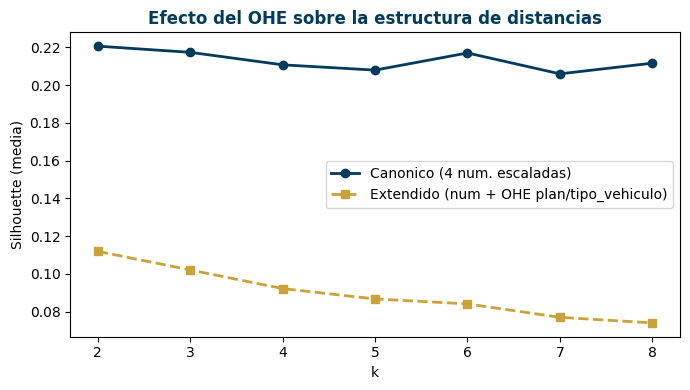

Decision de este material: espacio canonico numerico escalado como configuracion base.

CONCLUSIONES:
El que máximiza la media es 2, aunque en 8 cluster se tiene un incremento
Por lo tanto, consideraremos tomar 2 clusters


In [90]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = list(range(2, 9))
SILH_SAMPLE = 5_000

OHE_CATS = cat_features  # Variables que creemos afectaran más a los grupos.
assert set(OHE_CATS).issubset(set(FEATURE_COLUMNS))
assert set(OHE_CATS).isdisjoint(set(TARGET_COLUMNS))

ext_pre = ColumnTransformer([
    ("num", StandardScaler(), CLUSTERING_FEATURES),
    ("cat", OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False), OHE_CATS),
])
X_ext = ext_pre.fit_transform(df_autos_sinRuido[CLUSTERING_FEATURES + OHE_CATS])
print(f"Espacio extendido (num + OHE): {X_ext.shape[1]} dimensiones")

sil_canon, sil_ext = [], []
for k in K_RANGE:
    lc = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X)
    le = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X_ext)
    sil_canon.append(silhouette_score(X, lc, sample_size=SILH_SAMPLE, random_state=SEED))
    sil_ext.append(silhouette_score(X_ext, le, sample_size=SILH_SAMPLE, random_state=SEED))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_RANGE, sil_canon, "o-", color=NAVY, lw=2, label="Canonico (4 num. escaladas)")
ax.plot(K_RANGE, sil_ext, "s--", color=GOLD, lw=2, label="Extendido (num + OHE plan/tipo_vehiculo)")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette (media)")
ax.set_title("Efecto del OHE sobre la estructura de distancias", color=NAVY, fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()
print("Decision de este material: espacio canonico numerico escalado como configuracion base.")

print()
print('CONCLUSIONES:')
print('El que máximiza la media es 2, aunque en 8 cluster se tiene un incremento')
print('Por lo tanto, consideraremos tomar 2 clusters')

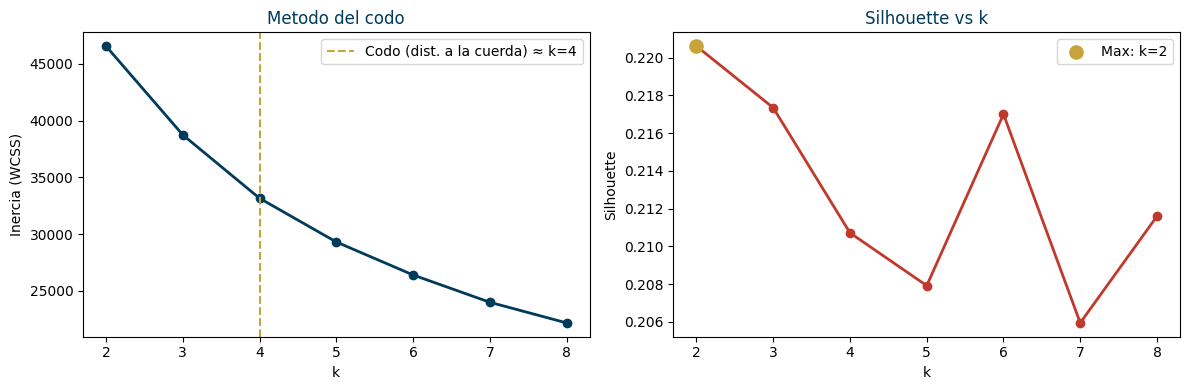

Codo (maxima distancia a la cuerda) sugiere k ≈ 4
Silhouette maximo en k=2 (silhouette=0.2206)
k seleccionada por codo + silhouette (la estabilidad se comprueba a continuacion).

CONCLUSIONES:
Si bien en el metodo del codo nos sugire tomar 4 cluster ya que es el que detecta con mayor inflexión,
el metodo de Silhouette coincide con la anterior vista de codo, en donde alcanza el punto máximo en 2 clusters
Por lo anterior, reforzamos nuestra propuesta de 2 grupos


In [91]:
def knee_index(y: np.ndarray) -> int:
    """Indice del punto de maxima distancia a la cuerda (determinista).

    Sobre una curva monotona ordenada, devuelve el indice del punto mas alejado de la
    recta que une el primer y el ultimo punto. Es una HEURISTICA del codo: solo sugiere
    un valor candidato, no una curvatura exacta ni una frontera cierta.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    x = np.arange(n, dtype=float)
    x1, x2, y1, y2 = x[0], x[-1], y[0], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.hypot(y2 - y1, x2 - x1)
    d = num / (den if den > 0 else 1.0)
    return int(np.argmax(d))


km_inertia, km_silhouette = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab = km.fit_predict(X)
    km_inertia.append(float(km.inertia_))
    km_silhouette.append(float(silhouette_score(X, lab, sample_size=SILH_SAMPLE, random_state=SEED)))

best_k = int(K_RANGE[int(np.argmax(km_silhouette))])
best_sil = float(max(km_silhouette))
elbow_k = int(K_RANGE[knee_index(np.array(km_inertia))])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_RANGE, km_inertia, "o-", color=NAVY, lw=2)
ax1.axvline(elbow_k, color=GOLD, ls="--", label=f"Codo (dist. a la cuerda) ≈ k={elbow_k}")
ax1.set_xlabel("k"); ax1.set_ylabel("Inercia (WCSS)"); ax1.set_title("Metodo del codo", color=NAVY); ax1.legend()
ax2.plot(K_RANGE, km_silhouette, "o-", color=RED, lw=2)
ax2.scatter([best_k], [best_sil], s=90, color=GOLD, zorder=5, label=f"Max: k={best_k}")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette"); ax2.set_title("Silhouette vs k", color=NAVY); ax2.legend()
plt.tight_layout(); plt.show()

print(f"Codo (maxima distancia a la cuerda) sugiere k ≈ {elbow_k}")
print(f"Silhouette maximo en k={best_k} (silhouette={best_sil:.4f})")
print("k seleccionada por codo + silhouette (la estabilidad se comprueba a continuacion).")

print()
print('CONCLUSIONES:')
print('Si bien en el metodo del codo nos sugire tomar 4 cluster ya que es el que detecta con mayor inflexión,')
print('el metodo de Silhouette coincide con la anterior vista de codo, en donde alcanza el punto máximo en 2 clusters')
print('Por lo anterior, reforzamos nuestra propuesta de 2 grupos')

In [92]:
from sklearn.metrics import adjusted_rand_score

# Estabilidad (comprobacion POSTERIOR): ARI entre ajustes con distinto random_state,
# cada uno con n_init=10, sobre las MISMAS 30,000 observaciones (ARI exige mismas obs.).
ref_lab = KMeans(n_clusters=best_k, n_init=10, random_state=SEED).fit_predict(X)
stab_aris = []
for s in (SEED + 1, SEED + 2, SEED + 3, SEED + 4, SEED + 5):
    lab_s = KMeans(n_clusters=best_k, n_init=10, random_state=s).fit_predict(X)
    stab_aris.append(float(adjusted_rand_score(ref_lab, lab_s)))
stab_ari_mean = float(np.mean(stab_aris))
print(f"Estabilidad — ARI medio entre {len(stab_aris)} ajustes con distinto random_state "
      f"(k={best_k}, n_init=10): {stab_ari_mean:.4f}")
print("(1.0 = particion identica entre ajustes; indica reproducibilidad de la solucion para el k ya")
print(" seleccionado bajo las semillas evaluadas; no selecciona k por si sola.)")
print(f"K-MEANS seleccion final: k={best_k}")

# Esto se hace para ver si la parte aleatoria nos llevo a esa selección de subclusters

Estabilidad — ARI medio entre 5 ajustes con distinto random_state (k=2, n_init=10): 1.0000
(1.0 = particion identica entre ajustes; indica reproducibilidad de la solucion para el k ya
 seleccionado bajo las semillas evaluadas; no selecciona k por si sola.)
K-MEANS seleccion final: k=2


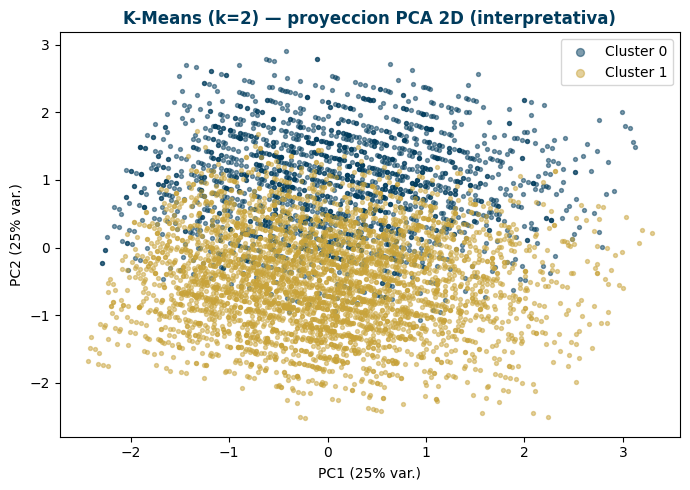

Inercia final (k=2): 46545.30
PC1+PC2 explican 50% de la varianza
Tamanos de cluster: [np.int64(4921), np.int64(9706)]


In [93]:
from sklearn.decomposition import PCA

km_final = KMeans(n_clusters=best_k, n_init=10, random_state=SEED)
km_labels = km_final.fit_predict(X)
km_inertia_final = float(km_final.inertia_)
km_sizes = pd.Series(km_labels).value_counts().sort_index()

pca = PCA(n_components=2, random_state=SEED).fit(X)
X_pca = pca.transform(X)
pca_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_pca), size=6000, replace=False)
for c in range(best_k):
    m = km_labels[idx] == c
    ax.scatter(X_pca[idx][m, 0], X_pca[idx][m, 1], s=8, alpha=0.5,
               color=CLUSTER_COLORS[c % len(CLUSTER_COLORS)], label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({pca_var[0]*100:.0f}% var.)"); ax.set_ylabel(f"PC2 ({pca_var[1]*100:.0f}% var.)")
ax.set_title(f"K-Means (k={best_k}) — proyeccion PCA 2D (interpretativa)", color=NAVY, fontweight="bold")
ax.legend(markerscale=2); plt.tight_layout(); plt.show()

print(f"Inercia final (k={best_k}): {km_inertia_final:.2f}")
print(f"PC1+PC2 explican {(pca_var[0]+pca_var[1])*100:.0f}% de la varianza")
print("Tamanos de cluster:", list(km_sizes.values))

In [94]:
prof = df_autos_sinRuido[CLUSTERING_FEATURES].copy()
prof["cluster"] = km_labels
profile_orig = prof.groupby("cluster").mean().round(1)
profile_orig["n"] = km_sizes.values
print("Perfil de cada cluster (unidades originales):")
print(profile_orig.to_string())

print()
print('CONCLUSIONES:')
print('- La variable que más discrimna es la Suma Asegurada')
print('- Con estos datos, podríamos cuestionarnos si considerar 2 clusters es lo más adecuado para segmentar la inforación,')
print('ya que fuera de la suma asegurada, el resto de los indicadores son muy similares.')

Perfil de cada cluster (unidades originales):
         edad  num_renovaciones  suma_asegurada  antiguedad_vehiculo     n
cluster                                                                   
0        43.3               1.2        700589.3                  1.4  4921
1        43.2               1.2        262523.2                  1.5  9706

CONCLUSIONES:
- La variable que más discrimna es la Suma Asegurada
- Con estos datos, podríamos cuestionarnos si considerar 2 clusters es lo más adecuado para segmentar la inforación,
ya que fuera de la suma asegurada, el resto de los indicadores son muy similares.


In [95]:
# ── ANALISIS POSTERIOR (interpretacion) — los targets NO formaron los clusters ──
post = df_autos_sinRuido[TARGET_COLUMNS].copy()
post["cluster"] = km_labels
resumen_post = post.groupby("cluster").agg(
    prima_neta_media=("prima_neta", "mean"),
    Costo_Promedio=("monto_pagado", "mean"),
    n_siniestros_medio=("n_siniestros", "mean"),
).round(3)
print("ANALISIS POSTERIOR (no formo los clusters) — perfil de targets por cluster:")
print(resumen_post.to_string())
print()
print('CONCLUSIONES:')
print('- Aquí podemos ver una mayor distinción en los grupos, por lo que si hace alguna diferenciación en todas las variables Target')
print("- Los segmentos de emision muestran distinta prima/siniestralidad media,")
print("pero esa relacion es descriptiva y posterior, no un insumo del clustering ni una verdad.")

ANALISIS POSTERIOR (no formo los clusters) — perfil de targets por cluster:
         prima_neta_media  Costo_Promedio  n_siniestros_medio
cluster                                                      
0               24288.762        4444.020               0.372
1                9292.886        4339.224               0.352

CONCLUSIONES:
- Aquí podemos ver una mayor distinción en los grupos, por lo que si hace alguna diferenciación en todas las variables Target
- Los segmentos de emision muestran distinta prima/siniestralidad media,
pero esa relacion es descriptiva y posterior, no un insumo del clustering ni una verdad.


#### Metodología K-Means: Con ruido vs Sin ruido

In [96]:
print('COMPARATIVO:')
print('En terminos generales no se muestra una diferencia importante, ya que ambas bases dan como resultado la propuesta de 2 clusters.')
print('El bajo nivel de variación se debe a que el ruido solo representa 125 registros de poco más de 14 mil, aunque las diferencias')
print('a destacar serían las siguientes:')
print('   - Se ve un apuntamiento mayor en la agrupación 6, por lo que sería una propuesta nueva de clusterización')
print('   - En las variables target, amplia ligeramente la diferencia entre los 2 clusters')

COMPARATIVO:
En terminos generales no se muestra una diferencia importante, ya que ambas bases dan como resultado la propuesta de 2 clusters.
El bajo nivel de variación se debe a que el ruido solo representa 125 registros de poco más de 14 mil, aunque las diferencias
a destacar serían las siguientes:
   - Se ve un apuntamiento mayor en la agrupación 6, por lo que sería una propuesta nueva de clusterización
   - En las variables target, amplia ligeramente la diferencia entre los 2 clusters
